<a href="https://colab.research.google.com/github/vedvy/Court-Vision-2026/blob/main/CSE327_Basketball_Jumpshot_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Basketball AI: Make or Miss - Jumpshot Detection

---

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/basketball-ai-make-or-miss-jumpshot-detection.ipynb)

![3-second-violations-1](https://media.roboflow.com/notebooks/basketball-ai-make-or-miss-jumpshot-detection.png)

## Before you start

### Configure your API key

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

Personal Notes:

Update: Ok, so the model I trained isn't as accurate as the one currently being used. But it can identify SK basketball games better than it, so I will integrate it here and hopefully we can derive enough from it for the timeline.

Unfortunately, this means that we'll need to be careful with our data and detections incase the model doesn't pick up on the features as well during analyzation. I wish I could train it more, but the limit on training tokens on Roboflow and time needed to label more data prevents it.

1. Vedant: I'll try to train and test the model on the Olympic game data, as well as get it to be responsive to NBA games outside the Celtics-Knicks ones. If i can have it be consistent on those in time, I'll get started on the timeline data.

2. It is important to note that we can focus solely on jumpshots at this moment, as layups are much more difficult to accurately track  players on.

3. For the jersey detections on jumpshots, trying the prev/next frame stratetgy could be beneficial, as we would be trying to see if the player with the ball in possession is the same as jumpshot early on to avoid misconstruing the final jersey number.

In [2]:
!pip install nbstripout
!nbstripout CSE327_Basketball_Jumpshot_Analysis.ipynb


Could not strip 'CSE327_Basketball_Jumpshot_Analysis.ipynb': file not found


In [ ]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

### Select the runtime

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Wed Jun 10 07:30:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [ ]:
import os

HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


### Install dependencies

**Note:** These commands install all the libraries required for this notebook. The `gdown` library is used to download example data from Google Drive. We use `inference-gpu` to run RF-DETR for player detection and a keypoint detection model for basketball court key points on GPUs. The `supervision` library is used to parse, process, and visualize model results, and the `sports` package provides basketball-specific utilities for analytics. This setup ensures you have everything needed for player detection, keypoint detection, and basketball analytics on GPU.

In [ ]:
!pip install -q gdown
!pip install -q inference-gpu
!pip install -q pytesseract
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q git+https://github.com/roboflow/sports.git@feat/basketball
!pip install -q moviepy
# !pip install --upgrade moviepy decorator
# !pip install -q --upgrade gdown
# !pip install -q inference-sdk inference
# !pip install -q --upgrade supervision
# %%capture
# import os, importlib.util
# !pip install --upgrade -qqq uv
# if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
#     try: import numpy, PIL; get_numpy = f"numpy=={numpy.__version__}"; get_pil = f"pillow=={PIL.__version__}"
#     except: get_numpy = "numpy"; get_pil = "pillow"
#     !uv pip install -qqq \
#         "torch>=2.8.0" "triton>=3.4.0" {get_numpy} {get_pil} torchvision bitsandbytes "transformers==4.56.2" \
#         "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
#         "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
#         git+https://github.com/triton-lang/triton.git@05b2c186c1b6c9a08375389d5efe9cb4c401c075#subdirectory=python/triton_kernels
# elif importlib.util.find_spec("unsloth") is None:
#     !uv pip install -qqq unsloth
# !uv pip install --upgrade --no-deps transformers==4.56.2 tokenizers trl==0.22.2


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done


**Note:** Set the ONNX Runtime execution provider to CUDA to ensure model inference runs on the GPU.

In [ ]:
import os

os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

**Note:** Download the sample video file using `gdown`. This file will be used for testing player detection and tracking.

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1eGYNis2WX5YU1GJ8jrkfxOufYj5_WpJX?q=sharedwith:public%20parent:1eGYNis2WX5YU1GJ8jrkfxOufYj5_WpJX
# !gdown 1KKEkdh-vQ0H5paPk2o__TZbmz7IztK_u --fuzzy
# from google.colab import drive
# drive.mount('/content/drive')
# FOLDER_DIR = "/content/drive/"
# !gdown --folder https://drive.google.com/drive/folders/1eGYNis2WX5YU1GJ8jrkfxOufYj5_WpJX
!gdown --folder https://drive.google.com/drive/folders/1RBjpI5Xleb58lujeusxH0W5zYMMA4ytO

Retrieving folder contents
Processing file 1KKEkdh-vQ0H5paPk2o__TZbmz7IztK_u boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4
Processing file 1AR_jjRteeBeKJubeQCULQAuks7HtsfBr boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4
Processing file 1m1eyLQz1KxTiNmUe3-k7nISJbYFajCS3 boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4
Processing file 12e3SHoe18PGv8adwa6squJ1vQM1jtxHT boston-celtics-new-york-knicks-game-1-q1-04.44-04.39.mp4
Processing file 1YXzSi9Y87TYjNTlJvDFVKHu-aNUIvGnE boston-celtics-new-york-knicks-game-1-q1-05.13-05.09.mp4
Processing file 1ybexxq8hhfYbpzUccddUMFZvZYmRD64- boston-celtics-new-york-knicks-game-1-q1-06.00-05.54.mp4
Processing file 1SfzuNIoG_shdM9WZ4mSZY8pdHR0-rLzk boston-celtics-new-york-knicks-game-1-q1-07.41-07.34.mp4
Processing file 149lS862zuLeVPa9UxiGmAL32orFC3JPG boston-celtics-new-york-knicks-game-1-q2-08.09-08.03.mp4
Processing file 1VBqhvaimmu29udqCpSLqkq0RDB5orRJk boston-celtics-new-york-knicks-game-1-q2-08.43-08.38.mp4
Processing

In [ ]:
from pathlib import Path

# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/half-court-shot-example.mp4"

#JUMPSHOT

#WORKS
#Rockets does not plot MADE on graph
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/Rockets-vs-Wolves-example1.mp4"
# SOURCE_ORIGINAL_PATH = "boston-celtics-new-york-knicks-game-1/Rockets-vs-Wolves-example1.mp4"
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4"
# SOURCE_ORIGINAL_PATH = "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4"
#JS detected, but jersey number wrong (4 instead of 8)
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4"
# SOURCE_ORIGINAL_PATH = "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4"
#JS detected, but jersey number wrong (0 because conf. was too low to get actual num)
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-04.44-04.39.mp4"

#JS detected, but jersey number wrong (1 instead of 2)
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-05.13-05.09.mp4"

#JS detected, but jersey number wrong (8 instead of 0)
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-06.00-05.54.mp4"

#JS detected, but jersey number couldn't be detected. MADE is properly graphed.
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-07.41-07.34.mp4"
# SOURCE_ORIGINAL_PATH = "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-07.41-07.34.mp4"
#JS detected, but jersey  number wrong (6 instead of 11)
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q2-08.43-08.38.mp4"

#JS detected, but jersey  number wrong (3 instead of 32)
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q2-10.36-10.32.mp4"

# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/Rockets-vs-GSW-Twenty-Second-Example.mp4"
#Still need to fix Olympic games

#ABle to detect ball being in basket, but not the jumpshot. CORRECTION, IT'S THE OPPOSITE.
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/Olympics-France-vs-US-q1-example1.mp4"
#Nope
SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/Olympics-France-US-q1-example2.mp4"
#WORKS
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/Olympics-France-US-q1-example3.mp4"
# SOURCE_ORIGINAL_PATH = "boston-celtics-new-york-knicks-game-1/Olympics-France-US-q1-example3.mp4"
#FIRST TWO MISSES ARE MARKED AS MADE, BUT WE CAN COUNT THE THIRD ATTEMPT AS BEING CORRECT
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/Olympics-Twenty-Second-Example.mp4"
# SOURCE_ORIGINAL_PATH = "boston-celtics-new-york-knicks-game-1/Olympics-Twenty-Second-Example.mp4"
#
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/South-Korea-FIBA-video-example-5.mp4"
#Stress  Test below
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/Korea-vs-China-Three-Minutes-Example.mp4"
# SOURCE_ORIGINAL_PATH = "boston-celtics-new-york-knicks-game-1/Korea-vs-China-Three-Minutes-Example.mp4"

#LAYUPS
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4"
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4"
#I need to fix this one in the visualization section. But num is seen as 8 instead of 23 unfortunately.
# SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q2-08.09-08.03.mp4"

### Imports

In [ ]:
import numpy as np
import supervision as sv
import pytesseract as pytess
import cv2
from tqdm import tqdm
from inference import get_model
from google.colab import userdata, drive
from google.colab.patches import cv2_imshow

from dataclasses import dataclass
from collections import deque
from typing import Union, Sequence, Optional, List

from sports import MeasurementUnit, ViewTransformer
from sports.basketball import (
    CourtConfiguration,
    League,
    draw_court,
    draw_made_and_miss_on_court,
    ShotEventTracker,
    ShotEvent,
    ShotType
)

from moviepy import *

[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL_YOLO_WORLD_ENABLED to False.


## ball, number, player, referee and basket detection

**Note:** The model used in this notebook detects the following classes: `ball`, `ball-in-basket`, `number`, `player`, `player-in-possession`, `player-jump-shot`, `player-layup-dunk`, `player-shot-block`, `referee`, and `rim`. These classes enable tracking of game events, player actions, and ball location for basketball analytics.

In [ ]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
SOUTH_KOREA_PLAYER_DETECTION_MODEL_ID = "olympic-sk-basketball-dataset-v2/14"
# SOUTH_KOREA_PLAYER_DETECTION_MODEL_ID = "olympic-sk-basketball-dataset-v2/13"
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID, api_key =  userdata.get("ROBOFLOW_API_KEY"))
SK_PLAYER_DETECTION_MODEL = get_model(model_id=SOUTH_KOREA_PLAYER_DETECTION_MODEL_ID, api_key=userdata.get("ROBOFLOW_API_KEY"))
# SK_PLAYER_DETECTION_MODEL_V2 = get_model(model_id=SOUTH_KOREA_PLAYER_DETECTION_MODEL_ID_V2, api_key=userdata.get("ROBOFLOW_API_KEY"))
COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

Output()

Output()

[3 3 3 3 3 3 3 7 2 7 2 3 2 7 8 3 2 0 2 1]


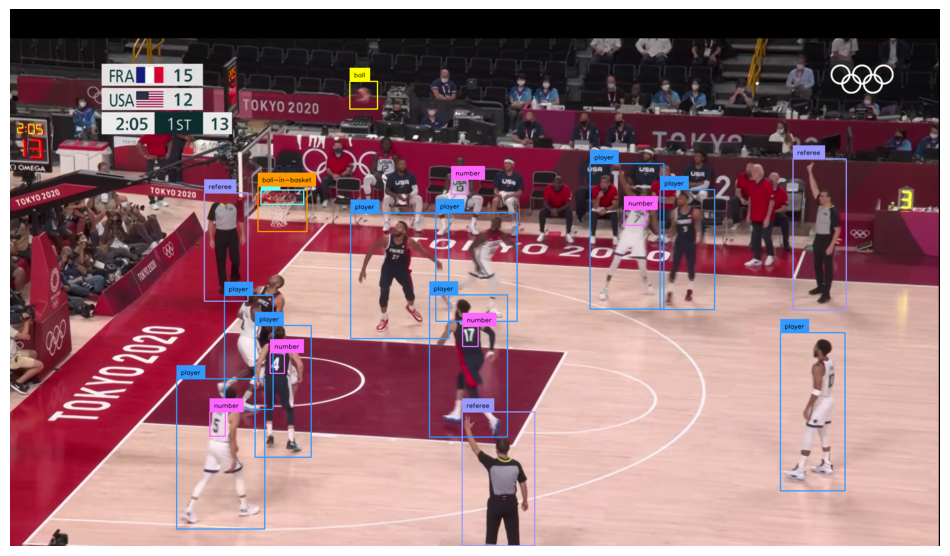

In [ ]:
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=65, iterative_seek=True)
frame = next(frame_generator)

result = SK_PLAYER_DETECTION_MODEL.infer(frame, confidence=0.25)[0]
detections = sv.Detections.from_inference(result)

print(detections.class_id)

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

## detect jump-shots

Jumpshot box:  []
jersey_box:  [[ 620.  819.  654.  868.]
 [1079.  756. 1116.  804.]
 [ 476.  960.  513. 1018.]
 [1052.  406. 1091.  441.]
 [1464.  478. 1514.  515.]]
Detections(xyxy=array([[ 620.,  819.,  654.,  868.],
       [1079.,  756., 1116.,  804.],
       [ 476.,  960.,  513., 1018.],
       [1052.,  406., 1091.,  441.],
       [1464.,  478., 1514.,  515.]]), mask=None, confidence=array([0.78553152, 0.70461273, 0.68433356, 0.53431731, 0.37664762]), class_id=array([2, 2, 2, 2, 2]), tracker_id=None, data={'class_name': array(['number', 'number', 'number', 'number', 'number'], dtype='<U14')}, metadata={})


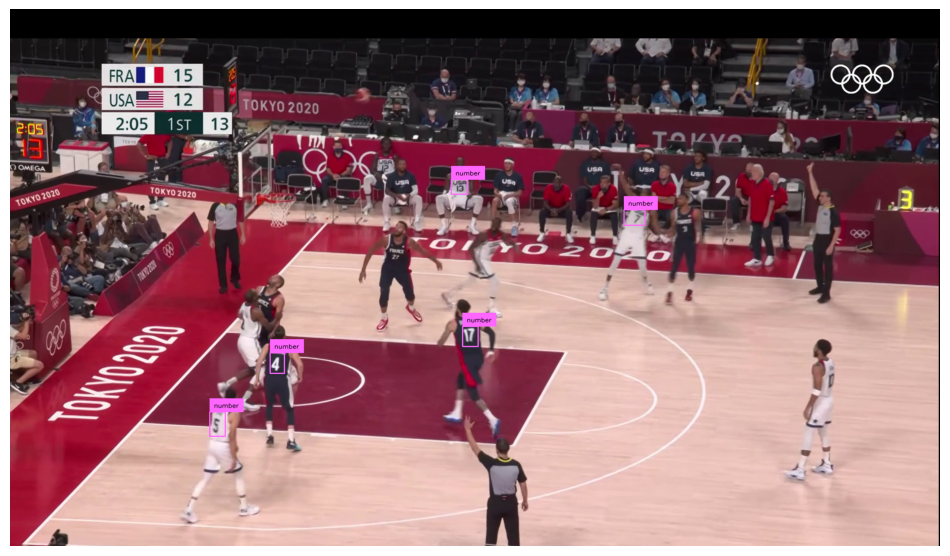

In [ ]:
def detect_num_in_jumpshot(num_box, jumpshot_box):
  return(num_box[0] >= jumpshot_box[0]
         and num_box[1] >= jumpshot_box[1]
         and num_box[2] <= jumpshot_box[2]
         and num_box[3] <= jumpshot_box[3])

#DETECT SHOT-EVENTS IS A BETTER CELL TO DETECT THE JUMPSHOTS, THOUGH SLOW DUE TO ITERATIVE PROCESS.

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=65, iterative_seek=True)
frame = next(frame_generator)

result = SK_PLAYER_DETECTION_MODEL.infer(frame, confidence=0.25)[0]
detections = sv.Detections.from_inference(result)
jumpshot_detections = detections[detections.class_id == 5]

#MY INSERTED CODE HERE
saved_path = os.path.join(HOME, "new_jersey_num.jpg")
jersey_detections = detections[detections.class_id == 2]

jumpshot_box = detections.xyxy[detections.class_id == 5]
print("Jumpshot box: ", jumpshot_box)
jersey_box = detections.xyxy[detections.class_id == 2]
print("jersey_box: ", jersey_box)
#following is just a pseudocode of detecting the jersey number in the jumpshot label?
if len(jersey_box) > 0 and len(jumpshot_box) == 1:
  for i in range(len(jersey_box)):
    if detect_num_in_jumpshot(jersey_box[i], jumpshot_box[0]):
      jersey_detections = jersey_detections[i]
      break
  #could use pytess if you can get the jersey detection as an image...
  jersey_crop = sv.crop_image(image=frame, xyxy=jersey_detections.xyxy)
  print("\n",jersey_crop.shape)

  #Saved the image!

  cv2.imwrite(saved_path, jersey_crop)
  #take the image from here:
  jersey_crop_jpg = cv2.imread("new_jersey_num.jpg")
  #attempt to make image bigger for pytess:
  jersey_crop_jpg = cv2.cvtColor(jersey_crop_jpg, cv2.COLOR_BGR2RGB)
  jersey_crop_jpg = cv2.resize(jersey_crop_jpg, (110,110), interpolation=cv2.INTER_CUBIC)

  #Make the image sharper/less blurry
  bias = 1.5
  kernal_size = (1,1)
  blur = cv2.GaussianBlur(jersey_crop_jpg, kernal_size, 0, 0)
  jersey_crop_jpg = cv2.addWeighted(jersey_crop_jpg, 1+bias, blur, -bias, 0)

  cv2_imshow(jersey_crop_jpg)

  number_data = pytess.image_to_string(jersey_crop_jpg, config='--psm 6')
  print(number_data)

#Notes
## Must determine how to obtain the singular jersey number from the jumpshot player. DONE!
## After that, the even tougher part is how do I extract enough info to confidently predict the number on the jersey?
## Once that is figured out, the rest is just inserting that number into the cells that annotate the 2d graph.

#merge jumpshot player label and jersey number
#KEEP JERSEY_DETECTIONS ACROSS THE CELLS, IT WILL BE NEEDED TO INFER THE NUMBER ON THE JERSEY.
print(jersey_detections)

detections = sv.Detections.merge([jumpshot_detections, jersey_detections])
#END OF MY CODE

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

## detect shot events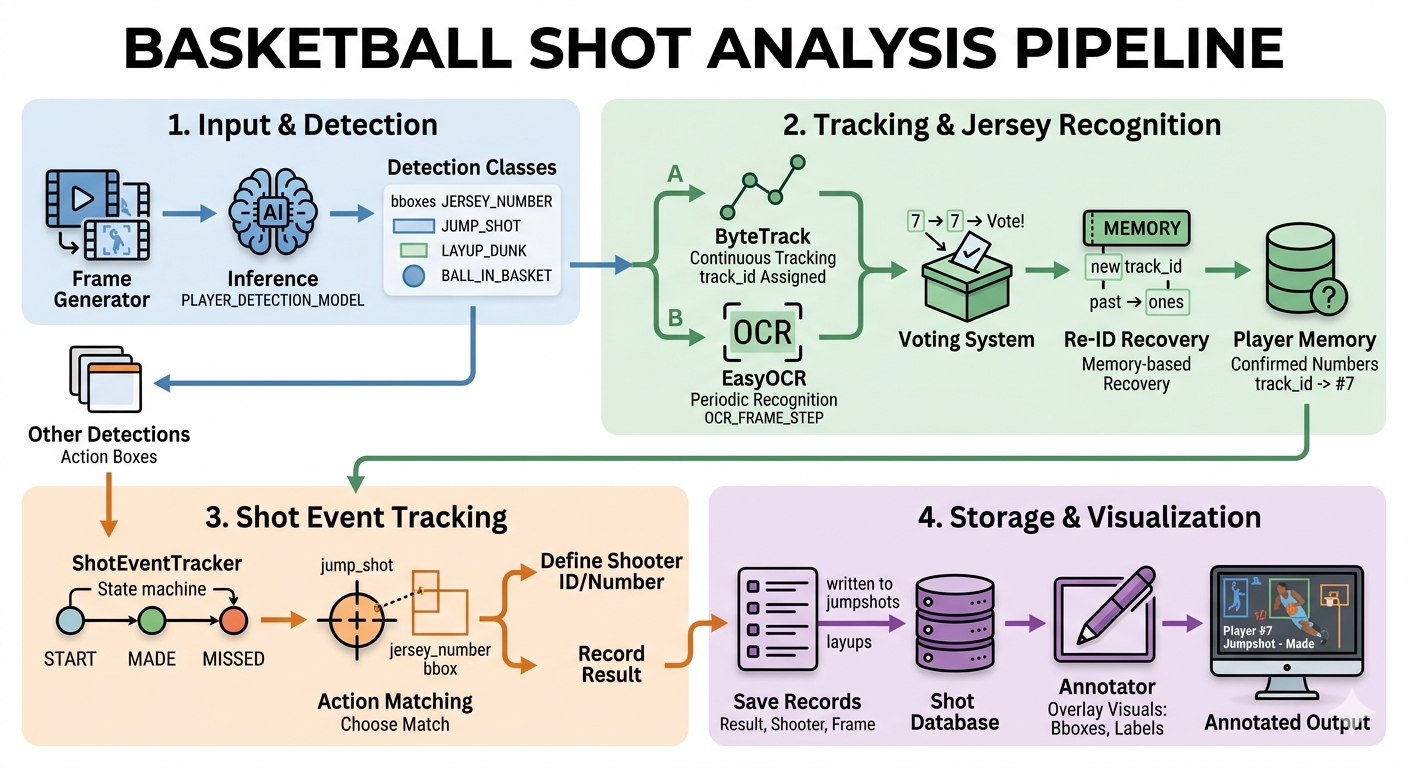

1. The number is already confirmed

- If the same number has already appeared multiple times in stage 2 and has been saved in player_number_memory, then the OCR in stage 3 does not run.

- Result: the system trusts the already verified number and avoids being misled by a blurry or occluded shot-moment frame.

2. The number is not confirmed yet, and the results differ
- If the numbers are different, the stage 3 result is added as another vote.

- Result: _get_number_for_track() then chooses the best available number from the vote history. For example, if stage 2 had one vote for 7 and stage 3 reads 10, the temporary result may become 10 because it is the latest vote.

3. The shot-moment OCR has high confidence

- If the confidence score from stage 3 is high, for example 0.65 or above, it updates track_last_number.
- Result: the system treats this as a strong recent observation, even if the number is not fully confirmed yet.

In [ ]:
# Eunha Choi - Updated on May 16th

# Import required libraries
# os: create folders and manage file paths
# re: extract numbers from OCR text using regular expressions
# cv2: OpenCV image processing
# numpy: numerical operations
# supervision: detection/annotation utilities
# pytesseract: OCR engine for reading jersey numbers
import os, re, cv2
import numpy as np
import supervision as sv
import pytesseract as tess

# Counter: count OCR voting results
# deque: store recent frames before and after shot events
from collections import Counter, deque

# dataclass: cleaner way to store configuration and event data
from dataclasses import dataclass, field


# ---------------------------------------------------------
# Configuration class
# ---------------------------------------------------------
# This stores all important thresholds and class IDs in one place.
# It makes the code easier to tune without changing many lines.
@dataclass
class Cfg:
    confidence: float = 0.35          # Detection confidence threshold
    iou: float = 0.70                 # IoU threshold for model inference

    # Class IDs from the detection model
    body: int = 0                     # Player/body class
    ball: int = 1                     # Ball-in-basket class
    jersey: int = 2                   # Jersey number class
    jump: int = 5                     # Jump shot class
    layup: int = 6                    # Layup/dunk class

    # Number of frames used around a shot event
    pre_frames: int = 6               # Frames before the shot start
    post_frames: int = 8              # Frames after the made/missed event

    # Minimum overlap between jersey box and action box
    jersey_overlap: float = 0.22

    # Minimum crop size for OCR
    min_w: int = 8
    min_h: int = 8

    # Padding added around jersey crop before OCR
    pad: float = 0.15

    # Debug image saving settings
    debug_dir: str = "/content/ocr_debug"
    save_debug: bool = False


# Create one global configuration object
C = Cfg()

# Create debug folder if it does not already exist
os.makedirs(C.debug_dir, exist_ok=True)


# ---------------------------------------------------------
# OCR setup
# ---------------------------------------------------------

# Some characters are often misread by OCR.
# This table converts common OCR mistakes into digits.
# Example: O -> 0, I -> 1, S -> 5, Z -> 2
SUBS = str.maketrans("OoIl|SsBZz", "0011155822")

# Tesseract OCR settings
# psm 7: treat image as a single text line
# psm 8: treat image as a single word
# whitelist limits OCR output to digits only
OCR_CFGS = [
    "--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789",
    "--oem 3 --psm 8 -c tessedit_char_whitelist=0123456789",
]

# Cache OCR results so the same frame/box is not processed repeatedly
OCR_CACHE = {}


# ---------------------------------------------------------
# Basic geometry helper functions
# ---------------------------------------------------------

def area(b):
    """
    Calculate the area of a bounding box.
    Box format: [x1, y1, x2, y2]
    """
    return max(0, b[2] - b[0]) * max(0, b[3] - b[1])


def center(b):
    """
    Calculate the center point of a bounding box.
    Returns [center_x, center_y].
    """
    return np.array([(b[0] + b[2]) / 2, (b[1] + b[3]) / 2], float)


def class_dets(dets, cls):
    """
    Filter detections by class ID.
    Example: get only jersey detections or only jump shot detections.
    """
    return dets[dets.class_id == cls]


def overlap(a, b):
    """
    Calculate how much box A overlaps with box B.
    The overlap is divided by the area of box A.

    This is useful for checking whether a jersey number box
    belongs to the detected shooting action box.
    """
    if a is None or b is None:
        return 0.0

    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    return intersection / max(area(a), 1)


def belongs(jersey, action):
    """
    Decide whether a jersey number box belongs to a shot action box.

    It returns True if:
    1. The jersey center is inside the action box, OR
    2. The jersey box overlaps enough with the action box.
    """
    if jersey is None or action is None:
        return False

    cx, cy = center(jersey)

    center_inside = action[0] <= cx <= action[2] and action[1] <= cy <= action[3]
    enough_overlap = overlap(jersey, action) >= C.jersey_overlap

    return center_inside or enough_overlap


# ---------------------------------------------------------
# Image crop and OCR preprocessing
# ---------------------------------------------------------

def crop(frame, box):
    """
    Crop the jersey number region from the frame.

    A small padding is added around the box because the detection box
    may be too tight and cut off part of the number.
    """
    h, w = frame.shape[:2]

    bw = box[2] - box[0]
    bh = box[3] - box[1]

    # Padding size is based on the larger side of the bounding box
    p = int(max(bw, bh) * C.pad)

    # Keep crop coordinates inside the image boundary
    x1 = max(0, int(box[0]) - p)
    y1 = max(0, int(box[1]) - p)
    x2 = min(w, int(box[2]) + p)
    y2 = min(h, int(box[3]) + p)

    # Return empty image if the crop is invalid
    return frame[y1:y2, x1:x2] if x2 > x1 and y2 > y1 else np.empty((0, 0, 3), np.uint8)


def norm(txt):
    """
    Normalize OCR text into a valid jersey number.

    Steps:
    1. Convert common OCR mistakes into digits.
    2. Extract only digit groups.
    3. Keep the longest number.
    4. Reject numbers longer than 2 digits.
    5. Remove leading zero from two-digit numbers like '07' -> '7'.
    6. Accept only numbers from 0 to 99.
    """
    nums = re.findall(r"\d+", str(txt or "").translate(SUBS))

    if not nums:
        return ""

    # Use the longest detected digit group
    n = max(nums, key=len)

    # Jersey number should not be longer than two digits
    if len(n) > 2:
        return ""

    # Convert 07 to 7
    if len(n) == 2 and n[0] == "0":
        n = n[1]

    return n if n.isdigit() and int(n) <= 99 else ""


def prep(img):
    """
    Prepare jersey crop image for OCR.

    The function creates two OCR-ready images:
    1. Normal binary threshold image
    2. Inverted binary threshold image

    This helps because some jerseys have dark numbers on light background,
    while others have light numbers on dark background.
    """
    h, w = img.shape[:2]

    # Enlarge small jersey crops to make OCR more reliable
    s = max(3, min(5, int(150 / max(h, w)) + 1))
    img = cv2.resize(img, (w * s, h * s), interpolation=cv2.INTER_CUBIC)

    # Convert to grayscale
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Improve contrast locally
    g = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(4, 4)).apply(g)

    # Reduce small noise
    g = cv2.GaussianBlur(g, (3, 3), 0)

    # Convert image to black and white using Otsu thresholding
    _, th = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Return both normal and inverted threshold images
    return [th, 255 - th]


def ocr_one(frame, box, idx, prefix=""):
    """
    Run OCR on one jersey number box.

    The same crop is tested with:
    - two preprocessed image versions
    - two Tesseract configurations

    The final result is chosen by voting.
    """
    # Cache key uses frame index and rounded box coordinates
    key = (idx, tuple(np.round(box).astype(int)))

    # Return cached result if this OCR was already done
    if key in OCR_CACHE:
        return OCR_CACHE[key]

    # Crop jersey number region
    img = crop(frame, box)

    # Ignore invalid or very small crops
    if img.size == 0 or img.shape[0] < C.min_h or img.shape[1] < C.min_w:
        OCR_CACHE[key] = ""
        return ""

    votes = Counter()

    # Try OCR on both normal and inverted images
    for i, im in enumerate(prep(img)):

        # Save debug image if enabled
        if C.save_debug:
            cv2.imwrite(f"{C.debug_dir}/{prefix}{idx}_{i}.jpg", im)

        # Try multiple OCR configurations
        for cfg in OCR_CFGS:
            n = norm(tess.image_to_string(im, config=cfg))

            # Count valid OCR result
            if n:
                votes[n] += 1

    # Choose the most common OCR result
    n = votes.most_common(1)[0][0] if votes else ""

    # Store result in cache
    OCR_CACHE[key] = n

    return n


def vote(nums):
    """
    Decide the final jersey number from multiple OCR results.

    Since OCR is not reliable on every frame, this function uses voting
    across several frames around the shot event.

    It returns:
    - the most reliable jersey number
    - "Unknown" if confidence is too weak
    """
    nums = [n for n in nums if n]

    if not nums:
        return "Unknown"

    c = Counter(nums)

    # If a two-digit number appears, give it small extra support
    # from matching single digits.
    # Example: if '40' appears and '4' or '0' also appears,
    # this slightly strengthens '40'.
    for n in list(c):
        if len(n) == 2:
            for d in n:
                c[n] += c.get(d, 0) * 0.2

    ranked = c.most_common()

    best, top = ranked[0]
    second = ranked[1][1] if len(ranked) > 1 else 0

    # Require at least two votes to avoid trusting one random OCR result
    if top < 2:
        return "Unknown"

    # If the best result is not clearly stronger than the second,
    # mark it as Unknown instead of guessing.
    if second and top < second * 1.45:
        return "Unknown"

    return best


# ---------------------------------------------------------
# Selecting action box and jersey box
# ---------------------------------------------------------

def best_action_box(dets, typ):
    """
    Select the most likely shot action box.

    For jump shots, it uses the jump shot class.
    For layups, it uses the layup/dunk class.

    If there are multiple action boxes, it prefers:
    - larger action boxes
    - boxes closer to the ball-in-basket detection
    """
    actions = class_dets(dets, C.jump if typ == "JUMP" else C.layup)

    if not len(actions):
        return None

    # Get ball center points
    balls = [center(b) for b in class_dets(dets, C.ball).xyxy]

    scores = []

    for b in actions.xyxy:
        # Base score: bigger action box is more likely important
        s = area(b)

        # If ball exists, prefer the action box closer to the ball
        if balls:
            nearest_ball_dist = min(np.linalg.norm(center(b) - p) for p in balls)
            s /= max(nearest_ball_dist, 1)

        scores.append(s)

    # Return the action box with highest score
    return actions.xyxy[int(np.argmax(scores))].copy()


def jersey_box(dets, action):
    """
    Find the jersey number box that most likely belongs to the shooter.

    It checks all jersey detections and keeps only the ones that belong
    to the action box. Then it chooses the best candidate based on:
    1. Higher overlap with the action box
    2. Closer distance to the action box center
    """
    jerseys = class_dets(dets, C.jersey)

    if action is None or not len(jerseys):
        return None

    ac = center(action)
    cand = []

    for i, j in enumerate(jerseys.xyxy):
        if belongs(j, action):
            cand.append((i, overlap(j, action), np.linalg.norm(center(j) - ac)))

    if not cand:
        return None

    # Sort by highest overlap first, then shortest distance
    cand.sort(key=lambda x: (-x[1], x[2]))

    return jerseys.xyxy[cand[0][0]].copy()


def choose_box(item, event):
    """
    Choose the jersey number box for a specific frame and shot event.

    It first tries to find the best action box in the current frame.
    If there is no action box in the current frame, it falls back to
    the action box stored when the event started.
    """
    action = best_action_box(item["dets"], event.type)

    return jersey_box(item["dets"], action if action is not None else event.action)


# ---------------------------------------------------------
# Shot event data structure
# ---------------------------------------------------------

@dataclass
class ShotEvent:
    """
    Stores all information related to one shot event.

    A shot event starts with START and ends with MADE or MISSED.
    During this event, the code collects OCR results from several frames.
    """
    type: str                         # "JUMP" or "LAYUP"
    start_idx: int                    # Frame index where shot started
    frame: np.ndarray                 # Frame image at shot start
    start_event: dict                 # Raw START event data
    action: object                    # Action box at start
    end_event: dict | None = None     # MADE or MISSED event data

    nums: list[str] = field(default_factory=list)  # OCR number results
    seen: set[int] = field(default_factory=set)    # Frames already scanned

    shooter: str = "Unknown"          # Final shooter jersey number
    shooter_id: object = None         # Optional shooter tracking ID
    until: int = 0                    # Last frame index to continue scanning


# ---------------------------------------------------------
# OCR resolver for shot events
# ---------------------------------------------------------

class ShotOcrResolver:
    """
    This class connects shot events with jersey OCR.

    Main idea:
    1. Store recent frames in a buffer.
    2. When a shot starts, scan nearby frames for jersey numbers.
    3. When the shot ends, scan more frames.
    4. Vote across all OCR results to decide the final shooter number.
    """

    def __init__(self, cfg):
        self.cfg = cfg

        # Pending shot events that have started but are not fully finalized
        self.pending = []

        # Frame buffer stores recent frames before the current frame
        self.buf = deque(maxlen=cfg.pre_frames + 1)

    def add_frame(self, idx, frame, dets):
        """
        Add the current frame and detections to the buffer.
        This allows OCR to use frames before the shot event starts.
        """
        self.buf.append({
            "idx": idx,
            "frame": frame.copy(),
            "dets": dets
        })

    def start(self, idx, frame, dets, raw, typ):
        """
        Called when a START event is detected.

        It creates a new ShotEvent and immediately scans recent frames
        because the jersey number may be clearer slightly before the shot.
        """
        e = ShotEvent(
            typ,
            idx,
            frame.copy(),
            raw,
            best_action_box(dets, typ),
            until=idx + self.cfg.post_frames
        )

        # Scan buffered frames around the start event
        self.scan(e, list(self.buf), f"START_{typ}_")

        # Keep this event until it receives MADE or MISSED
        self.pending.append(e)

    def finish(self, idx, raw, typ):
        """
        Called when a MADE or MISSED event is detected.

        It attaches the final result to the most recent pending event
        of the same type and extends scanning for a few more frames.
        """
        events = [e for e in self.pending if e.type == typ and e.end_event is None]

        # If there is no matching START event, return an Unknown record
        if not events:
            return {
                "frame": None,
                "start_event": None,
                "made_miss_event": raw,
                "shooter": "Unknown",
                "shooter_id": None
            }

        # Use the latest matching event
        e = events[-1]

        e.end_event = raw
        e.until = max(e.until, idx + self.cfg.post_frames)

        # Scan frames around the made/missed event
        self.scan(e, list(self.buf), f"END_{typ}_")

        # Return None because the event is not finalized yet
        return None

    def scan(self, e, items, prefix):
        """
        Scan selected frames for jersey numbers.

        For each frame:
        1. Choose the best jersey box.
        2. Run OCR on that box.
        3. Add valid OCR result to event.nums.
        4. Update the current best shooter using vote().
        """
        # Sort frames by closeness to the shot start frame
        for item in sorted(items, key=lambda x: abs(x["idx"] - e.start_idx)):

            # Skip frames already scanned for this event
            if item["idx"] in e.seen:
                continue

            # Select the jersey box that likely belongs to the shooter
            box = choose_box(item, e)

            if box is None:
                continue

            e.seen.add(item["idx"])

            # Run OCR on selected jersey box
            n = ocr_one(item["frame"], box, item["idx"], prefix)

            if n:
                e.nums.append(n)

        # Update shooter number if voting gives a confident result
        n = vote(e.nums)

        if n != "Unknown":
            e.shooter = n

    def update(self, idx, jumps, layups):
        """
        Called every frame.

        It continues scanning pending events until their scan window ends.
        When an event is complete, it is converted into a final record.
        """
        for e in self.pending[:]:

            # Continue scanning frames after the event
            if idx <= e.until:
                self.scan(e, list(self.buf)[-1:], f"POST_{e.type}_")

            # Finalize event after its post-frame window ends
            if e.end_event is not None and idx > e.until:
                e.shooter = vote(e.nums)

                if e.type == "JUMP":
                    jumps.append(self.record(e))
                else:
                    layups.append(self.record(e))

                self.pending.remove(e)

    def flush(self, jumps, layups):
        """
        Finalize remaining pending events after the video ends.

        This prevents completed events from being lost if the video ends
        before their normal post-frame window finishes.
        """
        for e in self.pending:
            if e.end_event is not None:
                if e.type == "JUMP":
                    jumps.append(self.record(e))
                else:
                    layups.append(self.record(e))

        self.pending.clear()

    @staticmethod
    def record(e):
        """
        Convert a ShotEvent object into a simple dictionary result.
        """
        return {
            "frame": e.frame,
            "start_event": e.start_event,
            "made_miss_event": e.end_event,
            "shooter": e.shooter,
            "shooter_id": e.shooter_id,
        }


# ---------------------------------------------------------
# Visualization setup
# ---------------------------------------------------------

# Color palette for drawing bounding boxes
COLOR = sv.ColorPalette.from_hex([
    "#ffff00",
    "#ff9b00",
    "#ff66ff",
    "#3399ff",
    "#ff66b2",
    "#ff8080",
    "#b266ff"
])

# Box annotator draws detection boxes
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)

# Label annotator draws text labels on boxes
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)


# ---------------------------------------------------------
# Video and shot tracker setup
# ---------------------------------------------------------

# Read video information such as FPS
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

# Create frame generator for reading video frame by frame
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

# ShotEventTracker detects START, MADE, and MISSED events.
# The frame thresholds are based on FPS so they scale with video speed.
shot_event_tracker = ShotEventTracker(
    reset_time_frames=int(video_info.fps * 1.7),
    minimum_frames_between_starts=int(video_info.fps * 0.5),
    cooldown_frames_after_made=int(video_info.fps * 0.5),
)

# OCR resolver handles shooter jersey number recognition
resolver = ShotOcrResolver(C)

# Final result lists
jumpshots_frames = []
layups_frames = []


# ---------------------------------------------------------
# Main video processing loop
# ---------------------------------------------------------

for frame_idx, frame in enumerate(frame_generator):

    # Run object detection model on current frame
    result = PLAYER_DETECTION_MODEL.infer(
        frame,
        confidence=C.confidence,
        iou_threshold=C.iou
    )[0]

    # Convert model output to supervision Detections format
    dets = sv.Detections.from_inference(result)

    # Store current frame in OCR buffer
    resolver.add_frame(frame_idx, frame, dets)

    # Update shot event tracker using current detections
    events = shot_event_tracker.update(
        frame_index=frame_idx,
        has_jump_shot=len(class_dets(dets, C.jump)) > 0,
        has_layup_dunk=len(class_dets(dets, C.layup)) > 0,
        has_ball_in_basket=len(class_dets(dets, C.ball)) > 0,
    )

    # Process all detected events in this frame
    for ev in events:
        typ = ev.get("type")       # "JUMP" or "LAYUP"
        name = ev.get("event")     # "START", "MADE", or "MISSED"

        print(ev)

        # Ignore events that are not jump shots or layups
        if typ not in ("JUMP", "LAYUP"):
            continue

        # Shot started
        if name == "START":
            resolver.start(frame_idx, frame, dets, ev, typ)

        # Shot ended as made or missed
        elif name in ("MADE", "MISSED"):
            rec = resolver.finish(frame_idx, ev, typ)

            # If there was no matching START event, save Unknown result
            if rec is not None:
                if typ == "LAYUP":
                    layups_frames.append(rec)
                else:
                    jumpshots_frames.append(rec)

    # Continue updating OCR resolver for pending shot events
    resolver.update(frame_idx, jumpshots_frames, layups_frames)

    # -----------------------------------------------------
    # Visualization when events are detected
    # -----------------------------------------------------
    if events:
        # Show only important detections:
        # jump shot, layup/dunk, jersey number, and ball-in-basket
        show = dets[
            (dets.class_id == C.jump)
            | (dets.class_id == C.layup)
            | (dets.class_id == C.jersey)
            | (dets.class_id == C.ball)
        ]

        annotated = frame.copy()

        if len(show):
            labels = []

            # Create labels for each detection box
            for box, cls in zip(show.xyxy, show.class_id):
                cls = int(cls)

                # For jersey boxes, run OCR and show detected number
                if cls == C.jersey:
                    n = ocr_one(frame, box, frame_idx, "PLOT_")
                    labels.append(f"#{n}" if n else "#?")

                # For other classes, show class name
                else:
                    labels.append({
                        C.ball: "ball",
                        C.jump: "jump",
                        C.layup: "layup"
                    }.get(cls, str(cls)))

            # Draw boxes and labels
            annotated = box_annotator.annotate(scene=annotated, detections=show)
            annotated = label_annotator.annotate(
                scene=annotated,
                detections=show,
                labels=labels
            )

        # Display annotated frame
        sv.plot_image(annotated)


# ---------------------------------------------------------
# Finalize and print results
# ---------------------------------------------------------

# Finalize any remaining completed shot events
resolver.flush(jumpshots_frames, layups_frames)

print(f"\n{'=' * 55}")
print(f"Jumpshots: {len(jumpshots_frames)} | Layups: {len(layups_frames)}")

# Print final shooter number for each shot event
for name, records in [("Jumpshot", jumpshots_frames), ("Layup", layups_frames)]:
    if records:
        print(f"\n-- {name} records --")

    for r in records:
        print(f"  {r['made_miss_event']} shooter: #{r['shooter']}")

In [ ]:

# ORIGINAL + VEDANT VYAS
# Use a similar cell like this, obtain the jumpshot frame, then use that as the basis of court keypoints and detection

import re
from collections import deque
from dataclasses import dataclass, field

VALID_JERSEY_NUMBERS = {str(i) for i in range(100)}
TRACK_KEEP_FRAMES = 12
STABLE_VOTE_THRESHOLD = 3.0
MAX_MATCH_DISTANCE_RATIO = 0.75

def detect_num_in_jumpshot(num_box, jumpshot_box):
  return(num_box[0] >= jumpshot_box[0]
         and num_box[1] >= jumpshot_box[1]
         and num_box[2] <= jumpshot_box[2]
         and num_box[3] <= jumpshot_box[3])

@dataclass
class JerseyNumberTrack:
    track_id: int
    last_box: np.ndarray
    last_seen: int
    votes: deque = field(default_factory=lambda: deque(maxlen=20))
    stable_number: str = ""
    stable_score: float = 0.0

    def add_vote(self, number: str, confidence: float, frame_index: int, box: np.ndarray):
        self.votes.append((number, confidence))
        self.last_seen = frame_index
        self.last_box = box
        self._compute_stable_number()

    def _compute_stable_number(self):
        counts = {}
        for number, confidence in self.votes:
            if not number:
                continue
            counts[number] = counts.get(number, 0.0) + max(0.1, confidence)
        if not counts:
            return
        best_number, best_score = max(counts.items(), key=lambda item: item[1])
        if best_score >= STABLE_VOTE_THRESHOLD:
            self.stable_number = best_number
            self.stable_score = best_score

    def is_active(self, frame_index: int) -> bool:
        return (frame_index - self.last_seen) <= TRACK_KEEP_FRAMES

class JerseyNumberTrackManager:
    def __init__(self):
        self.tracks = []
        self.next_id = 0

    def prune(self, frame_index: int):
        self.tracks = [track for track in self.tracks if track.is_active(frame_index)]

    def match_track(self, box: np.ndarray):
        center = _box_center(box)
        best_track = None
        best_distance = float('inf')
        for track in self.tracks:
            candidate = _box_center(track.last_box)
            distance = float(np.linalg.norm(center - candidate))
            if distance < best_distance:
                best_distance = distance
                best_track = track
        if best_track is None:
            return None
        box_size = max(box[2] - box[0], box[3] - box[1])
        if best_distance <= box_size * MAX_MATCH_DISTANCE_RATIO:
            return best_track
        return None

    def update(self, frame_index: int, boxes: np.ndarray, frame: np.ndarray):
        self.prune(frame_index)
        results = []
        for box in boxes:
            track = self.match_track(box)
            if track is None:
                track = JerseyNumberTrack(
                    track_id=self.next_id,
                    last_box=box.copy(),
                    last_seen=frame_index,
                )
                self.next_id += 1
                self.tracks.append(track)
            else:
                track.last_box = box.copy()
                track.last_seen = frame_index

            if not track.stable_number:
                number, confidence = _recognize_jersey_number(frame, box)
                if number:
                    track.add_vote(number, confidence, frame_index, box.copy())

            results.append((box.copy(), track))
        return results


def _box_center(box: np.ndarray) -> np.ndarray:
    return np.array([(box[0] + box[2]) / 2.0, (box[1] + box[3]) / 2.0], dtype=float)


def _normalize_jersey_text(text: str) -> str:
    if not text:
        return ""
    digits = re.findall(r'\d{1,2}', text)
    if not digits:
        return ""
    number = max(digits, key=len)
    if number.startswith('0') and len(number) == 2:
        number = number.lstrip('0') or '0'
    if number in VALID_JERSEY_NUMBERS:
        return number
    return ""


def _recognize_jersey_number(frame: np.ndarray, box: np.ndarray) -> tuple[str, float]:
    x1, y1, x2, y2 = [int(v) for v in box]
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return "", 0.0

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (0, 0), fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    denoised = cv2.fastNlMeansDenoising(resized, None, h=10, templateWindowSize=7, searchWindowSize=21)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(denoised)
    _, thresh = cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

    ocr_config = '--psm 6 -c tessedit_char_whitelist=0123456789'
    data = pytess.image_to_data(morph, config=ocr_config, output_type=pytess.Output.DICT)
    text = ' '.join([word for word in data.get('text', []) if word.strip()])
    number = _normalize_jersey_text(text)
    confidences = [float(conf) for conf in data.get('conf', []) if isinstance(conf, str) and conf.isdigit()]
    confidence = min(1.0, max(0.0, sum(confidences) / max(len(confidences), 1) / 100.0))
    return number, confidence


def _choose_jersey_index(jersey_boxes: np.ndarray, jumpshot_box: np.ndarray):
    if len(jersey_boxes) == 0:
        return None
    jump_center = _box_center(jumpshot_box)
    best_idx, best_score = None, float('inf')
    for idx, box in enumerate(jersey_boxes):
        center = _box_center(box)
        if box[0] <= jump_center[0] <= box[2] and box[1] <= jump_center[1] <= box[3]:
            return idx
        score = float(np.linalg.norm(center - jump_center))
        if score < best_score:
            best_score = score
            best_idx = idx
    if best_idx is None:
        return None
    jumpshot_size = max(jumpshot_box[2] - jumpshot_box[0], jumpshot_box[3] - jumpshot_box[1])
    if best_score <= jumpshot_size * MAX_MATCH_DISTANCE_RATIO:
        return best_idx
    return None


jersey_number_manager = JerseyNumberTrackManager()


def jumpshot_and_jersey_detection(detections, frame, frame_index):
  jumpshot_box = detections.xyxy[detections.class_id == JUMP_SHOT_CLASS_ID]
  jersey_box = detections.xyxy[detections.class_id == 2]
  jersey_detections = detections[detections.class_id == 2]

  if len(jumpshot_box) != 1 or len(jersey_box) == 0:
    return detections

  matched_index = _choose_jersey_index(jersey_box, jumpshot_box[0])
  track_pairs = jersey_number_manager.update(frame_index, jersey_box, frame)

  if matched_index is None or matched_index >= len(track_pairs):
    return detections

  matched_track = track_pairs[matched_index][1]
  matched_jersey = jersey_detections[matched_index]

  if matched_track.stable_number:
    try:
      matched_jersey.labels = np.array([f"#{matched_track.stable_number}"])
    except Exception:
      pass
    print(f"Stable jersey #{matched_track.stable_number} on track {matched_track.track_id}")

  return sv.Detections.merge([detections[detections.class_id == JUMP_SHOT_CLASS_ID], matched_jersey])


# def find_made_miss_event(frame_index, frame_generator):
#   for new_frame_index, frame in enumerate(frame_generator):
#     result = PLAYER_DETECTION_MODEL.infer(
#         frame,
#         confidence=CONFIDENCE_THRESHOLD,
#         iou_threshold=IOU_THRESHOLD,
#     )[0]
#     detections = sv.Detections.from_inference(result)

#     has_jump_shot = len(detections[detections.class_id == JUMP_SHOT_CLASS_ID]) > 0
#     has_layup_dunk = len(detections[detections.class_id == LAYUP_DUNK_CLASS_ID]) > 0
#     has_ball_in_basket = len(detections[detections.class_id == BALL_IN_BASKET_CLASS_ID]) > 0

#     events = shot_event_tracker.update(
#         frame_index=frame_index,
#         has_jump_shot=has_jump_shot,
#         has_layup_dunk=has_layup_dunk,
#         has_ball_in_basket=has_ball_in_basket,
#     )
#     # print(new_frame_index, " vs ", frame_index)
#     if events:
#       if (new_frame_index > frame_index) and (events[0].get('event') == "MISSED" or events[0].get('event') == "MADE"):
#         return_frame_index = new_frame_index
#         made_miss_event = events[0]
#         break
#   print(return_frame_index, made_miss_event)
#   return return_frame_index, made_miss_event


CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.7

BALL_IN_BASKET_CLASS_ID = 1
JUMP_SHOT_CLASS_ID = 5
LAYUP_DUNK_CLASS_ID = 6

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

shot_event_tracker = ShotEventTracker(
    reset_time_frames=int(video_info.fps * 1.7),
    minimum_frames_between_starts=int(video_info.fps * 0.5),
    cooldown_frames_after_made=int(video_info.fps * 0.5),
)
#Should change this to be lists in case of longer video clips.
#Also need to account for start and made_miss frames!
jump_dict = [{'frame':None, 'start_event': None, 'made_miss_event': None}]
#Make this a list to store start and made_miss
layups_dict = [{'frame': None, 'start_event':None, 'made_miss_event': None}]
#Make this a list too

for frame_index, frame in enumerate(frame_generator):
    result = SK_PLAYER_DETECTION_MODEL.infer(
        frame,
        confidence=CONFIDENCE_THRESHOLD,
        iou_threshold=IOU_THRESHOLD,
    )[0]
    detections = sv.Detections.from_inference(result)

    has_jump_shot = len(detections[detections.class_id == JUMP_SHOT_CLASS_ID]) > 0
    has_layup_dunk = len(detections[detections.class_id == LAYUP_DUNK_CLASS_ID]) > 0
    has_ball_in_basket = len(detections[detections.class_id == BALL_IN_BASKET_CLASS_ID]) > 0

    events = shot_event_tracker.update(
        frame_index=frame_index,
        has_jump_shot=has_jump_shot,
        has_layup_dunk=has_layup_dunk,
        has_ball_in_basket=has_ball_in_basket,
    )
    #Added this to only identify jump shots.
    # detections = detections[detections.class_id == 5]
    # print("Number of jump shots: ", has_jump_shot)
    # print(events)

    if events:
        print(events[0])
        if events[0].get('type') == "LAYUP":
          #Store the start frame and start event in the  list, then iterate further until you reach a made or miss event and store that in the list. Then continue
          #the enumeration from there.
          if events[0].get('event') == "START":
            layup_frame = frame.copy()
            layup_start = events[0]
          else:
            made_miss_event = events[0]
            layups_dict.append({'frame': layup_frame, 'start_event': layup_start, 'made_miss_event': made_miss_event})

          # while(events[0].get('event') == "MISSED" or events[0].get('event') == "MADE"):

          # frame_index = new_idx

        elif events[0].get('type') == "JUMP":
          if events[0].get('event') == "START":
            jumpshot_frame = frame.copy()
            jumpshot_start = events[0]

            #DETECT SHOT-EVENTS IS A BETTER CELL TO DETECT THE JUMPSHOTS, THOUGH SLOW DUE TO ITERATIVE PROCESS.

            box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
            label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

            result = SK_PLAYER_DETECTION_MODEL.infer(jumpshot_frame, confidence=0.25)[0]
            detections = sv.Detections.from_inference(result)
            jumpshot_detections = detections[detections.class_id == 5]

            #MY INSERTED CODE HERE
            saved_path = os.path.join(HOME, "new_jersey_num.jpg")
            jersey_detections = detections[detections.class_id == 2]

            jumpshot_box = detections.xyxy[detections.class_id == 5]
            print("Jumpshot box: ", jumpshot_box)
            jersey_box = detections.xyxy[detections.class_id == 2]
            print("jersey_box: ", jersey_box)
            #following is just a pseudocode of detecting the jersey number in the jumpshot label?
            if len(jersey_box) > 0 and len(jumpshot_box) == 1:
              for i in range(len(jersey_box)):
                if detect_num_in_jumpshot(jersey_box[i], jumpshot_box[0]):
                  jersey_detections = jersey_detections[i]
                  break

              sv.plot_image(jumpshot_frame)
              jersey_crop = sv.crop_image(image=jumpshot_frame, xyxy=jersey_detections.xyxy)
              print("\n",jersey_crop.shape)

              #Saved the image!

              cv2.imwrite(saved_path, jersey_crop)
              #take the image from here:
              jersey_crop_jpg = cv2.imread("new_jersey_num.jpg")
              #attempt to make image bigger for pytess:
              jersey_crop_jpg = cv2.cvtColor(jersey_crop_jpg, cv2.COLOR_BGR2RGB)
              jersey_crop_jpg = cv2.resize(jersey_crop_jpg, (110,110), interpolation=cv2.INTER_CUBIC)

              #Make the image sharper/less blurry
              bias = 1.5
              kernal_size = (1,1)
              blur = cv2.GaussianBlur(jersey_crop_jpg, kernal_size, 0, 0)
              jersey_crop_jpg = cv2.addWeighted(jersey_crop_jpg, 1+bias, blur, -bias, 0)

              cv2_imshow(jersey_crop_jpg)

              number_data = pytess.image_to_string(jersey_crop_jpg, config='--psm 6')
              print(number_data)

              #Notes
              ## Must determine how to obtain the singular jersey number from the jumpshot player. DONE!
              ## After that, the even tougher part is how do I extract enough info to confidently predict the number on the jersey?
              ## Once that is figured out, the rest is just inserting that number into the cells that annotate the 2d graph.

              #merge jumpshot player label and jersey number
              #KEEP JERSEY_DETECTIONS ACROSS THE CELLS, IT WILL BE NEEDED TO INFER THE NUMBER ON THE JERSEY.
              print(jersey_detections)
              if (jersey_detections.confidence[0] < 0.75):
                print("Confidence not high enough, skipping.")
                break

              detections = sv.Detections.merge([jumpshot_detections, jersey_detections])
              #END OF MY CODE

              annotated_frame = frame.copy()
              annotated_frame = box_annotator.annotate(
                  scene=annotated_frame,
                  detections=detections)
              annotated_frame = label_annotator.annotate(
                  scene=annotated_frame,
                  detections=detections)

              sv.plot_image(annotated_frame)
          else:
            made_miss_event = events[0]
            jump_dict.append({'frame': jumpshot_frame, 'start_event': jumpshot_start, 'made_miss_event': made_miss_event})
            #Same should be done here too!

          # frame_index = new_idx


          # jumpshot_event.append(events[0])
          # jumpshot_frame.append(frame.copy())

        # if events[0].get('type') == "LAYUP" and layup_frame is None:
        #   layup_event = events[0]
        #   layup_frame = frame.copy()
        # elif events[0].get('type') == "JUMP" and jumpshot_frame is None:
        #   jumpshot_event = events[0]
        #   jumpshot_frame = frame.copy()

        detections = jumpshot_and_jersey_detection(detections, frame, frame_index)
        annotated_frame = frame.copy()
        annotated_frame = box_annotator.annotate(
            scene=annotated_frame,
            detections=detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections)

        sv.plot_image(annotated_frame)

## visualize jump-shots and layups

In [ ]:
#Visualizes Jumpshots AND Layups
#VEDANT VYAS + EUNHA CHOI
def visualize_shot(shot, jersey_num):
  print("Visualizing")
  frame, start_event, made_miss_event = shot['frame'], shot['start_event'], shot['made_miss_event']
  print("start event: ", start_event)
  result = PLAYER_DETECTION_MODEL.infer(frame, confidence=0.35)[0]
  detections = sv.Detections.from_inference(result)
  if(start_event.get('type') == "LAYUP"):
    detections = detections[detections.class_id == 6]
  elif start_event.get('type') == "JUMP":
    detections = detections[detections.class_id == 5]


  xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

  # small hack to conver points into detections
  xyxy = sv.pad_boxes(np.hstack((xy, xy)), px=1, py=1)
  detections = sv.Detections(xyxy=xyxy)

  # labels = [f"#{number_data} here"] * len(detections)
  print(made_miss_event.get('event'))
  if made_miss_event.get('event') == "MISSED":
    print("Shot Missed")
    labels = [f"{jersey_num} MISSED here"] * len(detections)
    COLOR = sv.Color.from_hex('#a32a0b')
  elif made_miss_event.get('event') == "MADE":
    print("Shot Made")
    labels = [f"{jersey_num} MADE here"] * len(detections)
    COLOR = sv.Color.from_hex('#007A33')

  # COLOR = sv.Color.from_hex('#ff00ff')
  TEXT_COLOR = sv.Color.WHITE

  triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#000000'),
    base=25,
    height=21,
    color_lookup=sv.ColorLookup.INDEX
)
  text_annotator = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=60,
    color=COLOR,
    text_color=TEXT_COLOR,
    text_offset=(0, -30),
    color_lookup=sv.ColorLookup.INDEX,
    text_position=sv.Position.TOP_CENTER
)
  annotated_frame = frame.copy()
  annotated_frame = triangle_annotator.annotate(
      scene=annotated_frame,
      detections=detections
  )
  annotated_frame = text_annotator.annotate(
      scene=annotated_frame,
      detections=detections,
      labels=labels
  )

  sv.plot_image(annotated_frame)

# frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=65, iterative_seek=True)
# # frame = next(frame_generator)
js_shooters = []
layup_shooters = []
print(len(jumpshots_frames), len(layups_frames))

#Figure out a backup in case jumpshots_frame and layups_frames have no records when a js or layup exists.

for name, records in [("Jumpshot", jumpshots_frames), ("Layup", layups_frames)]:
    if not records:
        continue

    print(f"\n── {name} records ──")

    for r in records:
        if name == "Jumpshot":
          print("Have a num for the jump: ", r['shooter'])
          js_shooters.append(r['shooter'])

        else:
          layup_shooters.append(r['shooter'])


for i in range(len(jump_dict)):
  if jump_dict[i]['frame'] is None:
    continue

  visualize_shot(jump_dict[i], js_shooters[i-1])

for i in range(len(layups_dict)):
  if layups_dict[i]['frame'] is None:
    continue
  visualize_shot(layups_dict[i], layup_shooters[i-1])

# if len(jumpshot_frame) > 0:
# #   visualize_shot(jumpshot_frame[0], jumpshot_event[0])
# #   print("JS EVENT:" , jumpshot_event[0])

# # if len(layup_frame) > 0:
# #   visualize_shot(layup_frame[0], layup_event[0])
# #   print("LAY EVENT: ", layup_event)

## detect basketball court keypoints

In [ ]:
COURT_DETECTION_MODEL_ID = "basketball-court-detection-2/14"
COURT_DETECTION_MODEL = get_model(model_id=COURT_DETECTION_MODEL_ID, api_key =  userdata.get("ROBOFLOW_API_KEY"))

MAGENTA_COLOR = sv.Color.from_hex('#FF1493')
CYAN_COLOR = sv.Color.from_hex('#00BFFF')

In [ ]:
vertex_annotator = sv.VertexAnnotator(color=MAGENTA_COLOR, radius=8)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=65, iterative_seek=True)
frame = next(frame_generator)

result = COURT_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
key_points = sv.KeyPoints.from_inference(result)

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=key_points)

sv.plot_image(annotated_frame)

## detect basketball court keypoints with high confidence

In [ ]:
vertex_annotator = sv.VertexAnnotator(color=MAGENTA_COLOR, radius=8)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=65, iterative_seek=True)
frame = next(frame_generator)

result = COURT_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
key_points = sv.KeyPoints.from_inference(result)
key_points = key_points[:, key_points.confidence[0] > 0.5]

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=key_points)

sv.plot_image(annotated_frame)

## mark jump-shot location

In [ ]:
CONFIG = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
#Configure Frames to use the ones obtained in detect shots events. Mark both made and miss (How can it be done with the function given?)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=65, iterative_seek=True)
frame = next(frame_generator)
# frame = jump_dict[1]['frame']
# frame = layups_frames[1]['frame']

# detect court keypoints
court_result = COURT_DETECTION_MODEL.infer(frame, confidence=0.35)[0]
key_points = sv.KeyPoints.from_inference(court_result)

keypoint_mask = key_points.confidence[0] > 0.5
have_enough_points = np.count_nonzero(keypoint_mask) >= 4

if have_enough_points:
    court_vertices_masked = np.array(CONFIG.vertices)[keypoint_mask]
    detected_on_image = key_points[:, keypoint_mask].xy[0]

    image_to_court = ViewTransformer(
        source=detected_on_image,
        target=court_vertices_masked,
    )

    # detect jump-shot
    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=0.35)[0]
    detections = sv.Detections.from_inference(result)
    #NEXT STEP: Find a way to make detections for both layup and jumpshot.
    image_xy = detections[detections.class_id == 5].get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

    #How do we plot multiple marks here?
    if len(image_xy) > 0:
        court_xy = image_to_court.transform_points(points=image_xy)

        court = draw_made_and_miss_on_court(
            config=CONFIG,
            made_xy=court_xy,
            miss_size=25,
            made_color=sv.Color.from_hex("#007A33"),
            miss_color=sv.Color.from_hex("#850101"),
            made_thickness=6,
            miss_thickness=6,
        )

        # court2 = draw_made_and_miss_on_court(
        #     config=CONFIG,
        #     miss_xy=court_xy,
        #     miss_size=25,
        #     made_color=sv.Color.from_hex("#007A33"),
        #     miss_color=sv.Color.from_hex("#850101"),
        #     made_thickness=6,
        #     miss_thickness=6,
        # )
        # print(court.shape)
        # court3 = zip(court, court2)

        sv.plot_image(court)



## Optical Flow Tracking

Going to quickly experiment with pytess here, if it doesn't work then it's all good.

In [ ]:
"""Eunha Choi (May 26th Update)"""

import cv2
import numpy as np
import supervision as sv

# ==============================================================================
# Config
# ==============================================================================

# 1. Core Execution & AI Model Control
START_FRAME = 65            # Skip the intro, start processing from this frame
CONF = 0.25                 # Filter out shaky/low-confidence AI predictions
IOU_TH = 0.70               # NMS threshold to merge overlapping ghost boxes
DETECT_EVERY = 2            # Run heavy AI model every N frames to save compute
INFER_WIDTH = 960           # Target width for downscaling before feeding to AI

# 2. Data Analysis & Visualization Limits
MAX_FRAMES = None           # Set to a number (e.g. 300) for a quick test run
ROSTER_MIN = 8              # Need at least this many players to trigger overview save
MAX_SHOW_EVENTS = 20        # Cap the final plots so we don't flood the notebook

# 3. Jumpshot State Machine Control
SHOT_END_MISSING = 6        # Wait this many frames before assuming the shot event ended

# 4. Object Tracking & Matching
TRACK_IOU = 0.20            # Min overlap needed to say "yeah, this is the same guy"
TRACK_DIST = 1.30           # Max distance jump allowed for tracking match
MAX_MISSED = 25             # Let a player vanish for N frames before dropping their ID

# 5. Player and Jumpshot De-duplication
DUP_IOU = 0.15              # Threshold to check if player and jumpshot boxes overlap
DUP_DIST = 0.80             # Proximity check to link jumpshot status to a player

# 6. Optical Flow (Lucas-Kanade) Settings
MIN_FLOW_POINTS = 5         # If features drop below this, tracking is lost
MAX_CORNERS = 60            # Max keypoints to track inside each player's box
QUALITY_LEVEL = 0.01        # Corner detection sensitivity threshold
MIN_DISTANCE = 6            # Keep keypoints spaced out so they don't bunch up

# Class IDs
BALL, JERSEY, PLAYER, JUMP, REF, RIM = 0, 2, 3, 5, 8, 9

# Visualization Setup
COLOR = sv.ColorPalette.from_hex(["#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080", "#b266ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"])
box_anno = sv.BoxAnnotator(color=COLOR, thickness=2)
label_anno = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)


# ==============================================================================
# Geometry & Helpers
# ==============================================================================
def iou(a, b):
    """Standard Intersection over Union (IoU) calculation."""
    inter = max(0, min(a[2], b[2]) - max(a[0], b[0])) * max(0, min(a[3], b[3]) - max(a[1], b[1]))
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-6)

def dist_ratio(a, b):
    """Get distance between box centers, normalized by the larger box size."""
    size = max(np.sqrt((a[2]-a[0])*(a[3]-a[1])), np.sqrt((b[2]-b[0])*(b[3]-b[1])), 1.0)
    return np.linalg.norm((a[:2]+a[2:])/2 - (b[:2]+b[2:])/2) / size

def clip_box(box, shape):
    """Keep bounding boxes inside frame boundaries to prevent crashing on crops."""
    return np.clip(box, [0, 0, 0, 0], [shape[1]-2, shape[0]-2, shape[1]-1, shape[0]-1]).astype(np.float32)


# ==============================================================================
# Inference & Filtering
# ==============================================================================
def infer(frame):
    """Downscale frame for fast AI tracking, then upscale results back."""
    h, w = frame.shape[:2]

    # Shrink if the video is huge (e.g. 4K or 1080p) to keep FPS high
    scale = INFER_WIDTH / w if w > INFER_WIDTH else 1.0
    small = cv2.resize(frame, (int(w * scale), int(h * scale))) if scale != 1.0 else frame

    # Grab the raw model output (batch size 1, so take index 0)
    dets = sv.Detections.from_inference(SK_PLAYER_DETECTION_MODEL.infer(small, confidence=CONF, iou_threshold=IOU_TH)[0])

    # Map the boxes back to the original video resolution
    if len(dets) and scale != 1.0:
        dets.xyxy /= scale
    return dets

def get_trackable_dets(dets):
    """Filter out double-detections (e.g. a guy tagged as both PLAYER and JUMP)."""
    if not len(dets): return dets

    players = dets.xyxy[dets.class_id == PLAYER]
    keep = [
        # Always keep regular player tags. For jumpshots, only keep them if
        # they aren't already sitting right on top of an existing player box.
        cid == PLAYER or (cid == JUMP and not any(iou(b, p) >= DUP_IOU or dist_ratio(b, p) <= DUP_DIST for p in players))
        for b, cid in zip(dets.xyxy, dets.class_id)
    ]
    return dets[np.array(keep)]


# ==============================================================================
# Optical Flow Tracker
# ==============================================================================
class FlowTracker:
    """Tracks players using pixel movement (Optical Flow) between AI frames."""
    def __init__(self):
        self.next_id, self.tracks, self.prev_gray = 1, {}, None
        self.lk_params = dict(winSize=(21, 21), maxLevel=3, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))

    def _get_points(self, gray, box):
        """Find reliable corner features inside a box to track."""
        x1, y1, x2, y2 = clip_box(box, gray.shape).astype(int)
        mask = np.zeros_like(gray)
        mask[y1:y2, x1:x2] = 255
        return cv2.goodFeaturesToTrack(gray, maxCorners=MAX_CORNERS, qualityLevel=QUALITY_LEVEL, minDistance=MIN_DISTANCE, mask=mask)

    def update(self, frame, dets=None):
        """Step tracking forward using pixel motion + snap to new AI detections."""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Step 1: Predict where players moved based on pixel tracking
        if self.prev_gray is not None:
            for tr in self.tracks.values():
                if tr["pts"] is None or len(tr["pts"]) < MIN_FLOW_POINTS:
                    tr["missed"] += 1; continue

                # Calculate pixel velocity
                new_pts, st, _ = cv2.calcOpticalFlowPyrLK(self.prev_gray, gray, tr["pts"], None, **self.lk_params)
                good_old, good_new = (tr["pts"][st.flatten()==1].reshape(-1, 2), new_pts[st.flatten()==1].reshape(-1, 2)) if new_pts is not None else ([], [])

                if len(good_new) < MIN_FLOW_POINTS:
                    tr["pts"] = None; tr["missed"] += 1; continue

                # Shift the whole bounding box by the median movement vector
                dx, dy = np.median(good_new - good_old, axis=0)
                tr["box"] = clip_box(tr["box"] + [dx, dy, dx, dy], gray.shape)
                tr["pts"] = good_new.reshape(-1, 1, 2)
                tr["missed"] = max(0, tr["missed"] - 1)

        # Step 2: Correct tracking drift using fresh AI detections (if available)
        if dets is not None:
            boxes, classes = dets.xyxy, dets.class_id
            candidates = [(dist_ratio(tr["box"], b) - 2*iou(tr["box"], b), tid, i)
                          for tid, tr in self.tracks.items() for i, b in enumerate(boxes)]

            # Match existing tracks to new boxes based on highest overlap/closeness
            used_t, used_b = set(), set()
            for score, tid, i in sorted([c for c in candidates if c[0] <= TRACK_DIST or iou(self.tracks[c[1]]["box"], boxes[c[2]]) >= TRACK_IOU]):
                if tid not in used_t and i not in used_b:
                    # Found a match! Update track with new box and refresh features
                    self.tracks[tid].update({"box": clip_box(boxes[i], gray.shape), "class": classes[i], "missed": 0, "pts": self._get_points(gray, boxes[i])})
                    used_t.add(tid); used_b.add(i)

            # Active tracks that didn't match an AI box get a penalty point
            for tid in self.tracks:
                if tid not in used_t: self.tracks[tid]["missed"] += 1

            # Unmatched AI boxes mean a new player entered the screen -> Assign new ID
            for i, b in enumerate(boxes):
                if i not in used_b:
                    b_clipped = clip_box(b, gray.shape)
                    self.tracks[self.next_id] = {"box": b_clipped, "class": classes[i], "missed": 0, "pts": self._get_points(gray, b_clipped)}
                    self.next_id += 1

        # Clean up dead tracks (players who left the screen)
        self.tracks = {k: v for k, v in self.tracks.items() if v["missed"] <= MAX_MISSED}
        self.prev_gray = gray
        return [{"id": k, **v} for k, v in self.tracks.items()]


# ==============================================================================
# Drawing & Main Logic
# ==============================================================================
def annotate(frame, dets, labels=None, title=None):
    """Helper to burn boxes, labels, and titles onto the image."""
    img = box_anno.annotate(scene=frame.copy(), detections=dets)
    img = label_anno.annotate(scene=img, detections=dets, labels=labels) if labels else img
    if title: cv2.putText(img, title, (24, 42), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3, cv2.LINE_AA)
    return img

def main():
    video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
    frames = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=START_FRAME, iterative_seek=True)
    tracker = FlowTracker()

    debug_img, overview_img, overview_idx = None, None, None
    best_count, best_idx, best_frame, best_tracks = 0, None, None, None
    optical_events, in_shot, missing_jump = [], False, 0

    for i, frame in enumerate(frames):
        if MAX_FRAMES and i >= MAX_FRAMES: break

        f_idx = START_FRAME + i
        should_detect = (i % DETECT_EVERY == 0)

        # Run AI on intervals, skip otherwise to save time
        dets = infer(frame) if should_detect else None
        people = get_trackable_dets(dets) if dets else None
        jumps = dets[dets.class_id == JUMP] if dets else sv.Detections.empty()

        # Grab a quick raw debug print on the very first AI frame
        if should_detect and debug_img is None:
            labels = [{BALL:"ball", JERSEY:"jersey", PLAYER:"player", JUMP:"jumpshot", REF:"referee", RIM:"rim"}.get(int(c), f"class {int(c)}") for c in dets.class_id]
            debug_img = annotate(frame, dets, labels)

        # Update tracker positions for this frame
        tracks = tracker.update(frame, people)

        # Keep tabs on the most crowded frame (useful for fallbacks)
        if len(tracks) > best_count:
            best_count, best_frame, best_tracks, best_idx = len(tracks), frame.copy(), [t.copy() for t in tracks], f_idx

        # Capture a nice roster overview image once we see enough players mapped
        if overview_img is None and len(tracks) >= ROSTER_MIN:
            t_dets = sv.Detections(xyxy=np.array([t["box"] for t in tracks]), class_id=np.zeros(len(tracks), int), confidence=np.ones(len(tracks)))
            overview_img = annotate(frame, t_dets, [f"ID {t['id']}" for t in tracks], f"Player ID overview | frame {f_idx}")
            overview_idx = f_idx

        # --- Jumpshot State Machine ---
        if should_detect:
            # Case A: Fresh shot event detected (wasn't shooting in previous frame)
            if len(jumps) and not in_shot:
                # Pick the largest jumpshot box if multiple exist
                jump_box = jumps.xyxy[np.argmax([(b[2]-b[0])*(b[3]-b[1]) for b in jumps.xyxy])]

                # Figure out who shot it by finding the player closest to the jumpshot box
                shooter, best_score = "Unknown", float("inf")
                for tr in tracks:
                    score = dist_ratio(tr["box"], jump_box) - 2*iou(tr["box"], jump_box)
                    if score < best_score and (iou(tr["box"], jump_box) >= 0.03 or dist_ratio(tr["box"], jump_box) <= 1.80):
                        best_score, shooter = score, tr["id"]

                # Lock down the event image with shooter ID highlighted
                t_dets = sv.Detections(xyxy=np.array([t["box"] for t in tracks]), class_id=np.zeros(len(tracks), int), confidence=np.ones(len(tracks)))
                labels = [f"ID {t['id']}" + (" shooter" if t["id"]==shooter else "") for t in tracks]
                evt_img = annotate(annotate(frame, t_dets, labels, f"Jumpshot | frame {f_idx} | shooter ID {shooter}"), jumps, ["jumpshot"] * len(jumps))

                optical_events.append({"frame": f_idx, "shooter": shooter, "img": evt_img, "num_ids": len(tracks), "num_jumps": len(jumps)})
                in_shot, missing_jump = True, 0

            # Case B: Shot is still mid-air/ongoing
            elif len(jumps) and in_shot: missing_jump = 0

            # Case C: Jumpshot box vanished -> start cooldown countdown
            elif not len(jumps) and in_shot:
                missing_jump += 1
                if missing_jump >= SHOT_END_MISSING: in_shot, missing_jump = False, 0

    # Fallback: If we never hit ROSTER_MIN, use the most crowded frame as our overview
    if overview_img is None and best_frame is not None:
        t_dets = sv.Detections(xyxy=np.array([t["box"] for t in best_tracks]), class_id=np.zeros(len(best_tracks), int), confidence=np.ones(len(best_tracks)))
        overview_img = annotate(best_frame, t_dets, [f"ID {t['id']}" for t in best_tracks], f"Best ID overview | frame {best_idx}")
        overview_idx = best_idx

    # Flush final metrics to console
    print(f"\n{'='*55}\nFPS: {video_info.fps}\nStart frame: {START_FRAME}\nDetection interval: every {DETECT_EVERY} frame(s)")
    print(f"SHOT_END_MISSING: {SHOT_END_MISSING}\nOverview frame: {overview_idx}\nBest visible ID count: {best_count}\nJumpshot events: {len(optical_events)}")

    if debug_img is not None: print("\nDebug frame:"); sv.plot_image(debug_img)
    if overview_img is not None: print("\nOverview frame:"); sv.plot_image(overview_img)

    print("\nJumpshot event frames:")
    shooter_id_list = []
    for i, e in enumerate(optical_events[:MAX_SHOW_EVENTS]):
        print(f"Event {i+1}: frame {e['frame']} | shooter ID {e['shooter']} | IDs {e['num_ids']} | jumpshot boxes {e['num_jumps']}")
        shooter_id_list.append(e['shooter'])
        sv.plot_image(e["img"])
    return shooter_id_list

if __name__ == "__main__":
  #obtain optical events for filtering.
   shooter_ids = main()
  #  print(len(optical_events))
   print(shooter_ids)


## end-to-end multi-video processing

In [ ]:
CONFIG = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)

In [ ]:
COLOR = sv.ColorPalette.from_hex(['#007A33', '#006BB6'])
TEXT_COLOR = sv.Color.WHITE

triangle_annotator = sv.TriangleAnnotator(
    color=COLOR,
    base=25,
    height=21,
    color_lookup=sv.ColorLookup.CLASS
)
text_annotator = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=60,
    color=COLOR,
    text_color=TEXT_COLOR,
    text_offset=(0, -30),
    color_lookup=sv.ColorLookup.CLASS,
    text_position=sv.Position.TOP_CENTER
)

triangle_annotator_missed = sv.TriangleAnnotator(
    color=sv.Color.from_hex("#850101"),
    base=25,
    height=21,
    color_lookup=sv.ColorLookup.CLASS
)
text_annotator_missed = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=60,
    color=sv.Color.from_hex("#850101"),
    text_color=TEXT_COLOR,
    text_offset=(0, -30),
    color_lookup=sv.ColorLookup.CLASS,
    text_position=sv.Position.TOP_CENTER
)

In [ ]:
class KeyPointsSmoother:
    def __init__(self, length: int):
        self.length = length
        self.buffer = deque(maxlen=length)

    def update(
        self,
        xy: np.ndarray,
        confidence: Optional[np.ndarray] = None,
        conf_threshold: float = 0.0,
    ) -> np.ndarray:
        assert xy.ndim == 3 and xy.shape[0] == 1
        xy_f = xy.astype(np.float32, copy=True)

        if confidence is not None:
            assert confidence.shape[:2] == xy.shape[:2]
            mask = (confidence >= conf_threshold)[..., None]
            xy_f = np.where(mask, xy_f, np.nan)

        self.buffer.append(xy_f)
        stacked = np.stack(self.buffer, axis=0)

        if np.isnan(stacked).any():
            mean_xy = np.nanmean(stacked, axis=0)
        else:
            mean_xy = stacked.mean(axis=0)

        return mean_xy

In [ ]:
@dataclass
class Shot:
    x: float
    y: float
    distance: float
    result: bool
    team: int
    player_id: int

In [ ]:
def euclidean_distance(
    start_point: Union[Sequence[float], np.ndarray],
    end_point: Union[Sequence[float], np.ndarray]
) -> float:
    start_point_array = np.asarray(start_point, dtype=float)
    end_point_array = np.asarray(end_point, dtype=float)

    if start_point_array.shape != (2,) or end_point_array.shape != (2,):
        raise ValueError("Both points must have shape (2,).")

    return float(np.linalg.norm(end_point_array - start_point_array))

def extract_made(shots: list[Shot]):
    return [shot for shot in shots if shot.result]

def extract_xy(shots: list[Shot]):
    return np.array([[shot.x, shot.y] for shot in shots], dtype=float)

def extract_class_id(shots: list[Shot]):
    return np.array([shot.team for shot in shots], dtype=int)

def extract_label(shots: list[Shot]):
    return np.array([f"{shot.distance:.2f} ft" for shot in shots], dtype=str)

## Timeline Tracking

Vedant:
This is how I think the timeline could work

1. We give each mark on the 2D graph, not the frame visual one, an ID of the jersey number. The graph is going to be filled up with markings so it's important to note which number is associated with which. (Challenge: If two players, each on opposing teams, have the same number we will need to determine how to distinguish the two. But as of rn, it isn't necessary until later).

2. We need to be able to save the image and manually be given an option to filter out the players instead of rerunning the process everytime with a different player number. Python has a frontend system, but I'm unsure how good it will work with this. Either inputting the number or clicking on the marks can work, whichever is easier to implement honestly.

3. In the end-to-end processing function, we can override the shots list to be List[Shots, number] so that we store the shot and the identification of the jersey number. This way when we accumulate the markings in batches, we can filter out shots based on the jersey_numbers for analysis.


In [ ]:
# Timeline code
!pip install --upgrade moviepy

import moviepy
# from moviepy.video.io.VideoFileClip import VideoFileClip
# from moviepy.editor import *
import math

#Step 1: Have a large video file which we can divide into small batch videos to pass into the end-to-end video processor.
SOURCE_VIDEO_DIR = Path(HOME)
#Granted, this list will contain batches from a very long video, like a 15 minute video being processing into N number of 30 second clips.
SOURCE_VIDEO_NAMES = [

]

#Imagine this is a 15 minute, quarter length clip
SOURCE_VIDEO_PATH = Path(HOME) / "boston-celtics-new-york-knicks-game-1/boston-celtics-new-york-knicks-game-1-q2-10.36-10.32.mp4"

video = VideoFileClip(SOURCE_ORIGINAL_PATH)

clip_duration = 7

total_duration = video.duration
number_of_clips = math.ceil(total_duration / clip_duration)

for i in range(number_of_clips):
  start_clip = i * clip_duration
  end_clip = min((i+1) * clip_duration, total_duration)

  clip = video.subclipped(start_clip, end_clip)
  clip_filename = SOURCE_VIDEO_DIR / f"clip-{i+1}.mp4"

  clip.write_videofile(str(clip_filename), codec="libx264")
  # clip.ipython_display(width=480)
  #Save the video clip to the list to be added to the SOURCE_VIDEO_PATHS
  SOURCE_VIDEO_NAMES.append(clip_filename)

  # clip.close()

video.close()

SOURCE_VIDEO_PATHS = [
    video_name
    for video_name
    in SOURCE_VIDEO_NAMES
]

# print(SOURCE_VIDEO_PATHS[0].filename)

Our Version: USE THIS TO IMPLEMENT FUTURE TIMELINE FEATURES

Thinking about how we can provide a filtering system with the distance:

Vedant:

Update 06/01/26: I'm going to design a CV to better showcase the jumpshots distance, keep the numbers within the markings.

The filtering system will stay terminal for now, maybe changed up depending on time.

Experimentation with both models will be done, as well as number detection as well with optical flow and pytess.

A table will be made to show the distance of each shot made, with a list of the player_ids associated with each.

Lastly, I'll try out the longer video clips in the hopes that we obtain a good-enough court display.

Note to Self: If the confidence of the jersey id is low or possibly unknown based on the angle, we could just omit it from the court graph and move onto the next. Just the accurate ones can be graphed.

In [ ]:
KEYPOINT_CONFIDENCE_THRESHOLD = 0.5
DETECTION_CONFIDENCE = 0.3
CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.7

BALL_IN_BASKET_CLASS_ID = 1
JUMP_SHOT_CLASS_ID = 5
LAYUP_DUNK_CLASS_ID = 6

BALL_IN_BASKET_MIN_CONSECUTIVE_FRAMES = 2
JUMP_SHOT_MIN_CONSECUTIVE_FRAMES = 3
LAYUP_DUNK_MIN_CONSECUTIVE_FRAMES = 3

shots: List[Shot] = []

COURT_SCALE = 20
COURT_PADDING = 50
COURT_LINE_THICKNESS = 4
court_base = draw_court(
    config=CONFIG,
    scale=COURT_SCALE,
    padding=COURT_PADDING,
    line_thickness=COURT_LINE_THICKNESS,
)
court_h, court_w = court_base.shape[:2]
table_height = 200

for video_path in tqdm(SOURCE_VIDEO_PATHS, desc="Videos", position=0):

    # print("Video_Path: ", video_path.fps)

    target_video_path = (
        video_path.parent / f"{video_path.stem}-markers.mp4"
    )
    target_video_compressed_path = (
        target_video_path.parent
        / f"{target_video_path.stem}-compressed.mp4"
    )

    target_court_video_path = (
        video_path.parent / f"{video_path.stem}-court.mp4"
    )
    target_court_video_compressed_path = (
        target_court_video_path.parent
        / f"{target_court_video_path.stem}-compressed.mp4"
    )
    # print("VIDEO PATH: ", str(video_path))
    video_info = sv.VideoInfo.from_video_path(str(video_path))
    total_frames = getattr(
        video_info, "total_frames", getattr(video_info, "frame_count", None)
    )
    frame_generator = sv.get_video_frames_generator(str(video_path))

    court_video_info = sv.VideoInfo(
        width=court_w,
        height=court_h + table_height,
        fps=video_info.fps,
        total_frames=total_frames,
    )

    shot_event_tracker = ShotEventTracker(
        reset_time_frames=int(video_info.fps * 1.7),
        minimum_frames_between_starts=int(video_info.fps * 0.5),
        cooldown_frames_after_made=int(video_info.fps * 0.5),
    )

    smoother = KeyPointsSmoother(length=3)
    shot_in_progress_xy: Optional[np.ndarray] = None

    with sv.VideoSink(str(target_video_path), video_info) as sink, \
         sv.VideoSink(str(target_court_video_path), court_video_info) as court_sink:

        for frame_index, frame in tqdm(
            enumerate(frame_generator),
            total=int(total_frames) if total_frames else None,
            desc=f"Frames: {video_path.name}",
            position=1,
            leave=False,
        ):
            # ================= Player detections and state ================

            #Apply Optical Events here!

            player_result = SK_PLAYER_DETECTION_MODEL.infer(
                frame,
                confidence=CONFIDENCE_THRESHOLD,
                iou_threshold=IOU_THRESHOLD,
            )[0]
            player_detections = sv.Detections.from_inference(player_result)

            has_jump_shot = (
                len(player_detections[
                    player_detections.class_id == JUMP_SHOT_CLASS_ID
                ]) > 0
            )
            has_layup_dunk = (
                len(player_detections[
                    player_detections.class_id == LAYUP_DUNK_CLASS_ID
                ]) > 0
            )
            has_ball_in_basket = (
                len(player_detections[
                    player_detections.class_id == BALL_IN_BASKET_CLASS_ID
                ]) > 0
            )

            print("has ball in basket  is currently: ", has_ball_in_basket)
            #TO DO: Look into this updateer for some MADE jumpshots not being updated in this section! Like the Wolves clips.
            events = shot_event_tracker.update(
                frame_index=frame_index,
                has_jump_shot=has_jump_shot,
                has_layup_dunk=has_layup_dunk,
                has_ball_in_basket=has_ball_in_basket,
            )

            if has_jump_shot:
              print("Jumpshot was ATTEMPTED")

            if has_ball_in_basket:
                print("Jumpshot was MADE")
                print(events)
            # print("Was the ball in the basket? ", has_ball_in_basket)
            # print("Was there a jump shot? ", has_jump_shot)
            # ================= Court keypoints and transforms =============

            court_result = COURT_DETECTION_MODEL.infer(
                frame, confidence=DETECTION_CONFIDENCE
            )[0]
            key_points = sv.KeyPoints.from_inference(court_result)
            if key_points.xy.ndim == 3 and key_points.xy.shape[0] == 1:
              key_points.xy = smoother.update(
                  xy=key_points.xy,
                  confidence=key_points.confidence,
                  conf_threshold=0.5
              )
            elif key_points.xy.ndim == 3 and key_points.xy.shape[0] > 1:
                # Handle the rare case where multiple courts are found by stripping it down
                # to just the first (usually highest confidence) prediction to satisfy the smoother
                key_points.xy = smoother.update(
                    xy=key_points.xy[[0]],
                    confidence=key_points.confidence[[0]] if key_points.confidence is not None else None,
                    conf_threshold=0.5
                )
            else:
                # If key_points.xy is empty (shape[0] == 0), the court wasn't found in this frame.
                # You can choose to skip processing this frame or handle it cleanly:
                print("Court not detected in this frame, skipping smoothing.")
                # (Optional) code to handle empty keypoints goes here, e.g., continue
            # key_points.xy = smoother.update(xy=key_points.xy, confidence=key_points.confidence, conf_threshold=0.5)
            # print("Key Points: ", key_points)
            if key_points.confidence is None:
              continue
            # print("Key Points confidence: ", key_points.confidence[0])
            key_mask = key_points.confidence[0] > KEYPOINT_CONFIDENCE_THRESHOLD
            have_enough_points = np.count_nonzero(key_mask) >= 4

            if have_enough_points:
                court_vertices_masked = np.array(CONFIG.vertices)[key_mask]
                detected_on_image = key_points[:, key_mask].xy[0]

                image_to_court = ViewTransformer(
                    source=detected_on_image,
                    target=court_vertices_masked,
                )
                court_to_image = ViewTransformer(
                    source=court_vertices_masked,
                    target=detected_on_image,
                )

            # ================= Events and global shot list =================

            opt_event_idx = 0

            if events:
                start_events = [e for e in events if e["event"] == "START"]
                made_events = [e for e in events if e["event"] == "MADE"]
                print("Made Events Length: ", len(made_events))
                missed_events = [e for e in events if e["event"] == "MISSED"]

                if len(made_events) > 0:
                  print("The ball has been in the basket,  therefore we mark it as MADE")
                if len(missed_events) > 0:
                  print("The ball did not make it into the basekt from the jumpshot, there it's a MISS")

                if start_events and have_enough_points:
                    anchors_image = player_detections[
                        (player_detections.class_id == JUMP_SHOT_CLASS_ID)
                        | (player_detections.class_id == LAYUP_DUNK_CLASS_ID)
                    ].get_anchors_coordinates(
                        anchor=sv.Position.BOTTOM_CENTER
                    )
                    if len(anchors_image) > 0:
                        anchors_court = image_to_court.transform_points(
                            points=anchors_image
                        )
                        shot_in_progress_xy = anchors_court[0]

                if made_events and shot_in_progress_xy is not None:
                    shots.append(
                        Shot(
                            x=shot_in_progress_xy[0],
                            y=shot_in_progress_xy[1],
                            distance=euclidean_distance(
                                start_point=shot_in_progress_xy,
                                end_point=CONFIG.vertices[
                                    CONFIG.left_basket_index
                                ],
                            ),
                            result=True,
                            team=0,
                            player_id=shooter_ids[opt_event_idx],


                        )
                    )
                    opt_event_idx+=1
                    shot_in_progress_xy = None

                if missed_events and shot_in_progress_xy is not None:
                    shots.append(
                        Shot(
                            x=shot_in_progress_xy[0],
                            y=shot_in_progress_xy[1],
                            distance=euclidean_distance(
                                start_point=shot_in_progress_xy,
                                end_point=CONFIG.vertices[
                                    CONFIG.left_basket_index
                                ],
                            ),
                            result=False,
                            team=0,
                            player_id=shooter_ids[opt_event_idx],
                        )
                    )
                    opt_event_idx+=1
                    shot_in_progress_xy = None

            # ================= Render broadcast overlay ===================
            # filtered_shots = [s for s in shots if s.player_id == specific_jersey_id]
            annotated = frame.copy()
            if have_enough_points and len(shots) > 0:
                #TO DO: This part filters out shots if they contain the  filter shots. But maybe there's a cooler way to do this?

                made_shots = [s for s in shots if s.result is True]
                missed_shots = [s for s in shots if s.result is False]

                if len(made_shots) > 0:
                    made_xy_court = extract_xy(shots=made_shots)
                    made_xy_image = court_to_image.transform_points(
                        points=made_xy_court
                    )
                    boxes_xyxy_made = sv.pad_boxes(
                        np.hstack((made_xy_image, made_xy_image)),
                        px=1, py=1
                    )
                    classes_made = extract_class_id(shots=made_shots)
                    detections_made = sv.Detections(
                        xyxy=boxes_xyxy_made, class_id=classes_made
                    )
                    labels_made = [
                        f"{int(shot.distance)} feet" for shot in made_shots
                    ]
                    annotated = triangle_annotator.annotate(
                        scene=annotated, detections=detections_made
                    )
                    annotated = text_annotator.annotate(
                        scene=annotated,
                        detections=detections_made,
                        labels=labels_made,
                    )

                if len(missed_shots) > 0:
                    missed_xy_court = extract_xy(shots=missed_shots)
                    missed_xy_image = court_to_image.transform_points(
                        points=missed_xy_court
                    )
                    boxes_xyxy_missed = sv.pad_boxes(
                        np.hstack((missed_xy_image, missed_xy_image)),
                        px=1, py=1
                    )
                    classes_missed = extract_class_id(shots=missed_shots)
                    detections_missed = sv.Detections(
                        xyxy=boxes_xyxy_missed, class_id=classes_missed
                    )
                    labels_missed = ["missed"] * len(missed_shots)
                    annotated = triangle_annotator_missed.annotate(
                        scene=annotated, detections=detections_missed
                    )
                    annotated = text_annotator_missed.annotate(
                        scene=annotated,
                        detections=detections_missed,
                        labels=labels_missed,
                    )

            sink.write_frame(annotated)

            # ================= Render court map video =====================


            court_frame = court_base.copy()
            if len(shots) > 0:
                made_xy = np.array(
                    [(s.x, s.y) for s in shots if s.result is True],
                    dtype=float,
                )
                miss_xy = np.array(
                    [(s.x, s.y) for s in shots if s.result is False],
                    dtype=float,
                )
            else:
                made_xy = np.empty((0, 2), dtype=float)
                miss_xy = np.empty((0, 2), dtype=float)

            court_frame = draw_made_and_miss_on_court(
                config=CONFIG,
                made_xy=made_xy,
                miss_xy=miss_xy,
                court=court_frame,
                made_size=25,
                miss_size=25,
                made_color=sv.Color.from_hex("#007A33"),
                miss_color=sv.Color.from_hex("#850101"),
                made_thickness=6,
                miss_thickness=6,
                scale=COURT_SCALE,
                padding=COURT_PADDING,
                line_thickness=COURT_LINE_THICKNESS,
            )

            #A way to plot the jersey numbers onto the court graph
            for shot in shots:
                pixel_x = int(shot.x * COURT_SCALE + COURT_PADDING)
                pixel_y = int(shot.y * COURT_SCALE + COURT_PADDING)
                #text should be of the actual player_id, not the optical  event itself!!
                # Should also include the distance of the shot
                # Is it better to have a table at the bottom of the graph? If so, how should we discern which point is which?
                cv2.putText(
                    img=court_frame,
                    text=str(f"#{shot.player_id}"),
                    org=(pixel_x, pixel_y), # Offset so it doesn't overlap the marker
                    fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                    fontScale=1.75,
                    color=(0,0,0), # Black text
                    thickness=3,
                    lineType=cv2.LINE_AA
                )
            # --- 1. Expand the Canvas Downward ---
            # We add a 200-pixel tall black border at the bottom specifically for the table

            court_frame_extended = cv2.copyMakeBorder(
                court_frame,
                top=0,
                bottom=table_height,
                left=0,
                right=0,
                borderType=cv2.BORDER_CONSTANT,
                value=[255, 255, 255] # White background
            )

            # --- 2. Table Layout Geometry Configuration ---
            # Geometry relative to the newly added bottom section
            start_y = court_h + 20   # Table starts 20px below the original court image
            table_left = 50          # Left margin
            row_height = 35
            col1_w = 150             # Width of the Player ID column
            col2_w = 150             # Width of the Distance column
            table_right = table_left + col1_w + col2_w

            # --- 3. Draw Header Background ---
            header_end_y = start_y + row_height
            cv2.rectangle(
                court_frame_extended,
                (table_left, start_y),
                (table_right, header_end_y),
                (40, 40, 40), # Dark gray background for headers
                thickness=-1  # Solid fill
            )

            # --- 4. Write Header Text ---
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.5
            font_thickness = 1
            text_color = (255,255,255) # White text


            # Header 1: Player ID
            cv2.putText(court_frame_extended, "Player ID", (table_left + 10, start_y + 23), font, font_scale, text_color, font_thickness, cv2.LINE_AA)
            # Header 2: Distance
            cv2.putText(court_frame_extended, "Distance", (table_left + col1_w + 10, start_y + 23), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

            # --- 5. Populate Rows Dynamically ---
            current_y = header_end_y

            # Only show the last few shots so it doesn't overflow the designated table height
            max_rows = 4
            for shot in shots[-max_rows:]:
                next_y = current_y + row_height

                # Draw zebra-striping background alternating rows for readability
                bg_color = (20, 20, 20) if (shots.index(shot) % 2 == 0) else (10, 10, 10)
                cv2.rectangle(court_frame_extended, (table_left, current_y), (table_right, next_y), bg_color, thickness=-1)

                # Draw cell borders
                cv2.rectangle(court_frame_extended, (table_left, current_y), (table_right, next_y), (70, 70, 70), thickness=1)

                # Format and draw Data Strings
                player_str = str(shot.player_id)
                dist_str = f"{int(shot.distance)} ft" if shot.result else f"{int(shot.distance)} ft (Miss)"

                # Color code text: green for makes, red for misses
                data_color = (51, 210, 0) if shot.result else (1, 1, 210) # BGR Format

                cv2.putText(court_frame_extended, player_str, (table_left + 10, current_y + 23), font, font_scale, (255, 255, 255), font_thickness, cv2.LINE_AA)
                cv2.putText(court_frame_extended, dist_str, (table_left + col1_w + 10, current_y + 23), font, font_scale, data_color, font_thickness, cv2.LINE_AA)

                current_y = next_y

            # Draw the vertical column divider line line
            cv2.line(court_frame_extended, (table_left + col1_w, start_y), (table_left + col1_w, current_y), (100, 100, 100), thickness=1)

            # --- 6. Send to Sink ---
            # Update your video sink to use the extended dimensions
            # (Note: court_video_info height should be updated to: court_h + table_height)
            court_sink.write_frame(court_frame_extended)
            # court_sink.write_frame(court_frame)

    # ====================== Compress with ffmpeg ======================
    print(f"Compressing {target_video_path.name} ...")
    !ffmpeg -y -i "{target_video_path}" -vcodec libx264 -crf 28 "{target_video_compressed_path}"
    print(f"Saved {target_video_compressed_path.name}")

    print(f"Compressing {target_court_video_path.name} ...")
    !ffmpeg -y -i "{target_court_video_path}" -vcodec libx264 -crf 28 "{target_court_video_compressed_path}"
    print(f"Saved {target_court_video_compressed_path.name}")

Original Version

In [ ]:
KEYPOINT_CONFIDENCE_THRESHOLD = 0.5
DETECTION_CONFIDENCE = 0.3
CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.7

BALL_IN_BASKET_CLASS_ID = 1
JUMP_SHOT_CLASS_ID = 5
LAYUP_DUNK_CLASS_ID = 6

BALL_IN_BASKET_MIN_CONSECUTIVE_FRAMES = 2
JUMP_SHOT_MIN_CONSECUTIVE_FRAMES = 3
LAYUP_DUNK_MIN_CONSECUTIVE_FRAMES = 3

shots: List[Shot] = []

COURT_SCALE = 20
COURT_PADDING = 50
COURT_LINE_THICKNESS = 4
court_base = draw_court(
    config=CONFIG,
    scale=COURT_SCALE,
    padding=COURT_PADDING,
    line_thickness=COURT_LINE_THICKNESS,
)
court_h, court_w = court_base.shape[:2]

for video_path in tqdm(SOURCE_VIDEO_PATHS, desc="Videos", position=0):

    # print("Video_Path: ", video_path.filename)

    target_video_path = (
        video_path.parent / f"{video_path.stem}-markers{video_path.suffix}"
    )
    target_video_compressed_path = (
        target_video_path.parent
        / f"{target_video_path.stem}-compressed{target_video_path.suffix}"
    )

    target_court_video_path = (
        video_path.parent / f"{video_path.stem}-court{video_path.suffix}"
    )
    target_court_video_compressed_path = (
        target_court_video_path.parent
        / f"{target_court_video_path.stem}-compressed"
        f"{target_court_video_path.suffix}"
    )

    video_info = sv.VideoInfo.from_video_path(str(video_path))
    total_frames = getattr(
        video_info, "total_frames", getattr(video_info, "frame_count", None)
    )
    frame_generator = sv.get_video_frames_generator(str(video_path))

    court_video_info = sv.VideoInfo(
        width=court_w,
        height=court_h,
        fps=video_info.fps,
        total_frames=total_frames,
    )

    shot_event_tracker = ShotEventTracker(
        reset_time_frames=int(video_info.fps * 1.7),
        minimum_frames_between_starts=int(video_info.fps * 0.5),
        cooldown_frames_after_made=int(video_info.fps * 0.5),
    )

    smoother = KeyPointsSmoother(length=3)
    shot_in_progress_xy: Optional[np.ndarray] = None

    with sv.VideoSink(str(target_video_path), video_info) as sink, \
         sv.VideoSink(str(target_court_video_path), court_video_info) as court_sink:

        for frame_index, frame in tqdm(
            enumerate(frame_generator),
            total=int(total_frames) if total_frames else None,
            desc=f"Frames: {video_path.name}",
            position=1,
            leave=False,
        ):
            # ================= Player detections and state ================

            player_result = PLAYER_DETECTION_MODEL.infer(
                frame,
                confidence=CONFIDENCE_THRESHOLD,
                iou_threshold=IOU_THRESHOLD,
            )[0]
            player_detections = sv.Detections.from_inference(player_result)

            has_jump_shot = (
                len(player_detections[
                    player_detections.class_id == JUMP_SHOT_CLASS_ID
                ]) > 0
            )
            has_layup_dunk = (
                len(player_detections[
                    player_detections.class_id == LAYUP_DUNK_CLASS_ID
                ]) > 0
            )
            has_ball_in_basket = (
                len(player_detections[
                    player_detections.class_id == BALL_IN_BASKET_CLASS_ID
                ]) > 0
            )

            events = shot_event_tracker.update(
                frame_index=frame_index,
                has_jump_shot=has_jump_shot,
                has_layup_dunk=has_layup_dunk,
                has_ball_in_basket=has_ball_in_basket,
            )

            # ================= Court keypoints and transforms =============

            court_result = COURT_DETECTION_MODEL.infer(
                frame, confidence=DETECTION_CONFIDENCE
            )[0]
            key_points = sv.KeyPoints.from_inference(court_result)
            key_points.xy = smoother.update(xy=key_points.xy, confidence=key_points.confidence, conf_threshold=0.5)

            key_mask = key_points.confidence[0] > KEYPOINT_CONFIDENCE_THRESHOLD
            have_enough_points = np.count_nonzero(key_mask) >= 4

            if have_enough_points:
                court_vertices_masked = np.array(CONFIG.vertices)[key_mask]
                detected_on_image = key_points[:, key_mask].xy[0]

                image_to_court = ViewTransformer(
                    source=detected_on_image,
                    target=court_vertices_masked,
                )
                court_to_image = ViewTransformer(
                    source=court_vertices_masked,
                    target=detected_on_image,
                )

            # ================= Events and global shot list =================

            if events:
                start_events = [e for e in events if e["event"] == "START"]
                made_events = [e for e in events if e["event"] == "MADE"]
                missed_events = [e for e in events if e["event"] == "MISSED"]

                if start_events and have_enough_points:
                    anchors_image = player_detections[
                        (player_detections.class_id == JUMP_SHOT_CLASS_ID)
                        | (player_detections.class_id == LAYUP_DUNK_CLASS_ID)
                    ].get_anchors_coordinates(
                        anchor=sv.Position.BOTTOM_CENTER
                    )
                    if len(anchors_image) > 0:
                        anchors_court = image_to_court.transform_points(
                            points=anchors_image
                        )
                        shot_in_progress_xy = anchors_court[0]

                if made_events and shot_in_progress_xy is not None:
                    shots.append(
                        Shot(
                            x=shot_in_progress_xy[0],
                            y=shot_in_progress_xy[1],
                            distance=euclidean_distance(
                                start_point=shot_in_progress_xy,
                                end_point=CONFIG.vertices[
                                    CONFIG.left_basket_index
                                ],
                            ),
                            result=True,
                            team=0,
                        )
                    )
                    shot_in_progress_xy = None

                if missed_events and shot_in_progress_xy is not None:
                    shots.append(
                        Shot(
                            x=shot_in_progress_xy[0],
                            y=shot_in_progress_xy[1],
                            distance=euclidean_distance(
                                start_point=shot_in_progress_xy,
                                end_point=CONFIG.vertices[
                                    CONFIG.left_basket_index
                                ],
                            ),
                            result=False,
                            team=0,
                        )
                    )
                    shot_in_progress_xy = None

            # ================= Render broadcast overlay ===================

            annotated = frame.copy()
            if have_enough_points and len(shots) > 0:
                made_shots = [s for s in shots if s.result is True]
                missed_shots = [s for s in shots if s.result is False]

                if len(made_shots) > 0:
                    made_xy_court = extract_xy(shots=made_shots)
                    made_xy_image = court_to_image.transform_points(
                        points=made_xy_court
                    )
                    boxes_xyxy_made = sv.pad_boxes(
                        np.hstack((made_xy_image, made_xy_image)),
                        px=1, py=1
                    )
                    classes_made = extract_class_id(shots=made_shots)
                    detections_made = sv.Detections(
                        xyxy=boxes_xyxy_made, class_id=classes_made
                    )
                    labels_made = [
                        f"{int(shot.distance)} feet" for shot in made_shots
                    ]
                    annotated = triangle_annotator.annotate(
                        scene=annotated, detections=detections_made
                    )
                    annotated = text_annotator.annotate(
                        scene=annotated,
                        detections=detections_made,
                        labels=labels_made,
                    )

                if len(missed_shots) > 0:
                    missed_xy_court = extract_xy(shots=missed_shots)
                    missed_xy_image = court_to_image.transform_points(
                        points=missed_xy_court
                    )
                    boxes_xyxy_missed = sv.pad_boxes(
                        np.hstack((missed_xy_image, missed_xy_image)),
                        px=1, py=1
                    )
                    classes_missed = extract_class_id(shots=missed_shots)
                    detections_missed = sv.Detections(
                        xyxy=boxes_xyxy_missed, class_id=classes_missed
                    )
                    labels_missed = ["missed"] * len(missed_shots)
                    annotated = triangle_annotator_missed.annotate(
                        scene=annotated, detections=detections_missed
                    )
                    annotated = text_annotator_missed.annotate(
                        scene=annotated,
                        detections=detections_missed,
                        labels=labels_missed,
                    )

            sink.write_frame(annotated)

            # ================= Render court map video =====================

            court_frame = court_base.copy()
            if len(shots) > 0:
                made_xy = np.array(
                    [(s.x, s.y) for s in shots if s.result is True],
                    dtype=float,
                )
                miss_xy = np.array(
                    [(s.x, s.y) for s in shots if s.result is False],
                    dtype=float,
                )
            else:
                made_xy = np.empty((0, 2), dtype=float)
                miss_xy = np.empty((0, 2), dtype=float)

            court_frame = draw_made_and_miss_on_court(
                config=CONFIG,
                made_xy=made_xy,
                miss_xy=miss_xy,
                court=court_frame,
                made_size=25,
                miss_size=25,
                made_color=sv.Color.from_hex("#007A33"),
                miss_color=sv.Color.from_hex("#850101"),
                made_thickness=6,
                miss_thickness=6,
                scale=COURT_SCALE,
                padding=COURT_PADDING,
                line_thickness=COURT_LINE_THICKNESS,
            )

            court_sink.write_frame(court_frame)

    # ====================== Compress with ffmpeg ======================
    print(f"Compressing {target_video_path.name} ...")
    !ffmpeg -y -i "{target_video_path}" -vcodec libx264 -crf 28 "{target_video_compressed_path}"
    print(f"Saved {target_video_compressed_path.name}")

    print(f"Compressing {target_court_video_path.name} ...")
    !ffmpeg -y -i "{target_court_video_path}" -vcodec libx264 -crf 28 "{target_court_video_compressed_path}"
    print(f"Saved {target_court_video_compressed_path.name}")

In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

# Mount Google Drive to Colab
# force_remount=True is useful when the previous mount state is broken or unclear
drive.mount('/content/drive', force_remount=True)

# Destination folder inside Google Drive
dst_folder = Path("/content/drive/MyDrive/basketball_output")

# Create the destination folder if it does not already exist
dst_folder.mkdir(parents=True, exist_ok=True)

# Search for all mp4 files under /content
# Only keep output files that include markers, court, or compressed in the filename
mp4_files = [
    f for f in Path("/content").rglob("*.mp4")
    if any(key in f.name for key in ["markers", "court", "compressed"])
]

# Print how many output videos were found
print("found files:", len(mp4_files))

# Copy each output video to Google Drive
for f in mp4_files:
    out_path = dst_folder / f.name

    # copy2 keeps file metadata such as modification time
    shutil.copy2(f, out_path)

    print("copied:", f, "->", out_path)

print("done")

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>